# Amazon ML Challenge 2026 — Phase 1: Training-data EDA

**Task:** business entity resolution. Each Source 1 record must be linked to all records in Source 2 / Source 3 that refer to the same business.

**Scope of this notebook:** training data only (`data/raw/train_*.tsv`). The test set is not read, referenced or inspected.

**Memory rules followed here**
* All heavy work runs in **DuckDB** (spills to disk, capped at 4 GB RAM). No full pandas DataFrames.
* No S1×S2 / S1×S3 Cartesian joins. Blocking statistics are computed by **key aggregation**, using `Σ_k n1(k)·n2(k)`, never by materialising candidate pairs.
* RapidFuzz is only run on a **sample of ground-truth pairs** (100k) and on small samples of blocked pairs.
* pandas only ever holds small query results (≤ 100k rows).

## 1. Environment

In [1]:
import sys, os, re, time, json, random, platform, shutil
from pathlib import Path
import duckdb, pandas as pd, numpy as np, psutil, rapidfuzz
from rapidfuzz import fuzz
from rapidfuzz.process import cpdist
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

NB_T0 = time.time()
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_rows", 200)

PROJECT   = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW       = PROJECT / "data" / "raw"
PROCESSED = PROJECT / "data" / "processed"
EXP       = PROJECT / "experiments"
PROCESSED.mkdir(parents=True, exist_ok=True)
EXP.mkdir(parents=True, exist_ok=True)

FILES = {
    "s1": RAW / "train_source1.tsv",
    "s2": RAW / "train_source2.tsv",
    "s3": RAW / "train_source3.tsv",
    "gt": RAW / "train_ground_truth.tsv",
}
LABEL = {"s1": "Source 1", "s2": "Source 2", "s3": "Source 3", "gt": "Ground Truth"}
for k, p in FILES.items():
    assert p.exists(), p
    print(f"{LABEL[k]:<13} {p.relative_to(PROJECT)}  {p.stat().st_size/1e6:,.1f} MB")

DB_PATH = PROCESSED / "eda.duckdb"          # derived working DB (git-ignored); rebuilt from scratch on every run
KEEP_DB = False                              # delete it at the end - the disk on this machine is tight
for f in [DB_PATH, DB_PATH.with_suffix(".duckdb.wal")]:
    if f.exists():
        f.unlink()
free_gb = shutil.disk_usage(PROJECT).free / 1e9
print(f"Free disk: {free_gb:.1f} GB")
assert free_gb > 4, "need >4 GB free disk for the DuckDB working DB + spill"
con = duckdb.connect(str(DB_PATH))
con.execute("SET memory_limit='4GB'")
con.execute(f"SET threads={os.cpu_count()}")
con.execute(f"SET temp_directory='{PROCESSED / 'duckdb_tmp'}'")
con.execute("SET preserve_insertion_order=false")
con.execute("SET max_temp_directory_size='2GB'")   # fail fast instead of filling the disk

SUMMARY, TIMINGS = {}, {}
PROC = psutil.Process()

def q(sql, label=None, params=None):
    """Run SQL in DuckDB and return a small pandas DataFrame. Optionally record timing."""
    t = time.time()
    df = con.execute(sql, params or []).df()
    dt = time.time() - t
    if label:
        TIMINGS[label] = round(TIMINGS.get(label, 0) + dt, 2)
        print(f"[{label}: {dt:.1f}s]")
    return df

def x(sql, label=None):
    t = time.time()
    con.execute(sql)
    if label:
        TIMINGS[label] = round(TIMINGS.get(label, 0) + time.time() - t, 2)
        print(f"[{label}: {time.time()-t:.1f}s]")

def rss_gb():
    return PROC.memory_info().rss / 1e9

print(f"\nPython {sys.version.split()[0]} | {platform.platform()} | CPUs {os.cpu_count()} | RAM {psutil.virtual_memory().total/1e9:.1f} GB")
print(f"duckdb {duckdb.__version__} | pandas {pd.__version__} | rapidfuzz {rapidfuzz.__version__} | matplotlib {matplotlib.__version__}")
print(f"Process RSS: {rss_gb():.2f} GB")
SUMMARY["environment"] = {"python": sys.version.split()[0], "duckdb": duckdb.__version__, "pandas": pd.__version__,
                          "rapidfuzz": rapidfuzz.__version__, "cpus": os.cpu_count(),
                          "ram_gb": round(psutil.virtual_memory().total/1e9, 1), "duckdb_memory_limit": "4GB"}

Source 1      data/raw/train_source1.tsv  210.1 MB
Source 2      data/raw/train_source2.tsv  489.3 MB
Source 3      data/raw/train_source3.tsv  503.7 MB
Ground Truth  data/raw/train_ground_truth.tsv  127.0 MB
Free disk: 7.2 GB

Python 3.13.9 | macOS-27.0-arm64-arm-64bit-Mach-O | CPUs 8 | RAM 8.6 GB
duckdb 1.5.5 | pandas 3.0.6 | rapidfuzz 3.14.6 | matplotlib 3.11.2
Process RSS: 0.15 GB


## 2. Dataset Schema
First, sniff the dialect and inferred types straight from the files with `read_csv_auto` (default type inference). Then check them against the expected schema.

In [2]:
EXPECTED = {
    "s1": ["entity_id", "business_name", "business_address", "country"],
    "s2": ["entity_id", "business_name", "business_address", "country"],
    "s3": ["entity_id", "business_name", "business_address", "country"],
    "gt": ["source1_entity_id", "matched_entity_ids"],
}
schema_rows, dialect_rows = [], []
t = time.time()
for k, p in FILES.items():
    d = q(f"DESCRIBE SELECT * FROM read_csv_auto('{p}', delim='\t', header=true)")
    cols = d["column_name"].tolist()
    for c, ty in zip(d["column_name"], d["column_type"]):
        schema_rows.append({"file": LABEL[k], "column": c, "inferred_type": ty})
    s = q(f"SELECT Delimiter, Quote, Escape, HasHeader, SkipRows FROM sniff_csv('{p}', delim='\t', header=true)")
    dialect_rows.append({"file": LABEL[k], "n_columns": len(cols), "matches_expected": cols == EXPECTED[k],
                         **s.iloc[0].to_dict()})
TIMINGS["schema"] = round(time.time() - t, 2)
display(pd.DataFrame(dialect_rows))
display(pd.DataFrame(schema_rows))
assert all(r["matches_expected"] for r in dialect_rows), "schema differs from expectation!"
SUMMARY["schema"] = {LABEL[k]: {r["column"]: r["inferred_type"] for r in schema_rows if r["file"] == LABEL[k]} for k in FILES}

,file,n_columns,matches_expected,Delimiter,Quote,Escape,HasHeader,SkipRows
0,Source 1,4,True,\t,(empty),(empty),True,0
1,Source 2,4,True,\t,(empty),(empty),True,0
2,Source 3,4,True,\t,(empty),(empty),True,0
3,Ground Truth,2,True,\t,(empty),(empty),True,0


,file,column,inferred_type
0,Source 1,entity_id,VARCHAR
1,Source 1,business_name,VARCHAR
2,Source 1,business_address,VARCHAR
3,Source 1,country,VARCHAR
4,Source 2,entity_id,VARCHAR
5,Source 2,business_name,VARCHAR
6,Source 2,business_address,VARCHAR
7,Source 2,country,VARCHAR
8,Source 3,entity_id,VARCHAR
9,Source 3,business_name,VARCHAR


**Load once into DuckDB.** Every later query reads these tables, not the TSVs. `all_varchar=true` keeps IDs as text, since type inference already gives VARCHAR for every column. Empty TSV fields become SQL `NULL`.

To keep disk usage low, only **one** physical copy of each source is stored. Table `r{1,2,3}` holds the raw columns plus the basic-normalised `name_n` / `addr_n`. Everything else is a **view**:
* `s1..s3` are the raw columns.
* `e1..e3` add the exploratory alnum columns `name_a` / `addr_a`, computed on demand.
* `et` is the S2 ∪ S3 union with its true `src`.
* `pf` (later) is the true-pair view.

The normalisation macros are explained in §4.1.

A few S2/S1 address fields contain literal `"` characters. The sniffer picks **no quote char** (see the table above), so those values are kept verbatim and never merged across tabs. The raw line counts below confirm that no row was lost or merged.

In [3]:
con.execute(r"""CREATE OR REPLACE MACRO norm_basic(s) AS
  nullif(regexp_replace(trim(lower(s)), '\s+', ' ', 'g'), '')""")
con.execute(r"""CREATE OR REPLACE MACRO has_indic(s) AS regexp_matches(s, '[\x{0900}-\x{0DFF}]')""")
con.execute(r"""CREATE OR REPLACE MACRO norm_alnum(s) AS
  nullif(trim(regexp_replace(
      CASE WHEN has_indic(s) THEN lower(s) ELSE strip_accents(lower(s)) END,
      '[^\p{L}\p{M}\p{N}]+', ' ', 'g')), '')""")

t = time.time()
for k, p in FILES.items():
    src = f"read_csv_auto('{p}', delim='\t', header=true, all_varchar=true)"
    if k == "gt":
        x(f"CREATE TABLE gt AS SELECT * FROM {src}")
        continue
    i = k[1]
    x(f"""CREATE TABLE r{i} AS SELECT *, norm_basic(business_name) name_n, norm_basic(business_address) addr_n FROM {src}""")
    x(f"CREATE VIEW s{i} AS SELECT entity_id, business_name, business_address, country FROM r{i}")
    x(f"CREATE VIEW e{i} AS SELECT *, norm_alnum(business_name) name_a, norm_alnum(business_address) addr_a FROM r{i}")
# All match targets with their *actual* source (by table membership, not ID prefix)
x("CREATE VIEW et AS SELECT 'S2' AS src, * FROM e2 UNION ALL SELECT 'S3' AS src, * FROM e3")
con.execute("CHECKPOINT")
TIMINGS["load_tables"] = round(time.time() - t, 2)
print(f"Loaded 4 files in {time.time()-t:.1f}s | RSS {rss_gb():.2f} GB | DuckDB file {DB_PATH.stat().st_size/1e9:.2f} GB")

def raw_line_count(p, bs=1 << 24):
    n = 0
    with open(p, "rb") as f:
        while (b := f.read(bs)):
            n += b.count(b"\n")
    return n

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 4 files in 24.5s | RSS 1.52 GB | DuckDB file 1.48 GB


## 3. Dataset Size
This section gives exact row counts, cross-checked against raw newline counts (header excluded), and entity-ID uniqueness.

In [4]:
t = time.time()
rows = []
for k, p in FILES.items():
    n = con.execute(f"SELECT COUNT(*) FROM {k}").fetchone()[0]
    rows.append({"File": LABEL[k], "Rows": n, "raw_lines_minus_header": raw_line_count(p) - 1})
TIMINGS["row_counts"] = round(time.time() - t, 2)
rc = pd.DataFrame(rows)
rc["consistent"] = rc["Rows"] == rc["raw_lines_minus_header"]
display(rc.style.format({"Rows": "{:,}", "raw_lines_minus_header": "{:,}"}))
SUMMARY["row_counts"] = dict(zip(rc["File"], rc["Rows"].astype(int)))

,File,Rows,raw_lines_minus_header,consistent
0,Source 1,"2,206,821","2,206,821",True
1,Source 2,"5,034,616","5,034,616",True
2,Source 3,"5,285,603","5,285,603",True
3,Ground Truth,"2,206,821","2,206,821",True


In [5]:
uni = []
for k, col in [("s1", "entity_id"), ("s2", "entity_id"), ("s3", "entity_id"), ("gt", "source1_entity_id")]:
    r = con.execute(f"""SELECT COUNT(*), COUNT(DISTINCT {col}), COUNT(*) - COUNT({col}) FROM {k}""").fetchone()
    uni.append({"file": LABEL[k], "id_column": col, "total_rows": r[0], "unique_ids": r[1], "null_ids": r[2],
                "duplicate_id_rows": r[0] - r[1] - r[2], "pct_duplicate": round(100 * (r[0] - r[1] - r[2]) / r[0], 4)})
uni = pd.DataFrame(uni); display(uni)

# ID prefixes (informational only - source membership is established by table lookup, not by prefix)
display(q("""
SELECT 'Source 1' src, substr(entity_id,1,3) prefix, COUNT(*) n, MIN(length(entity_id)) min_len, MAX(length(entity_id)) max_len FROM s1 GROUP BY ALL
UNION ALL SELECT 'Source 2', substr(entity_id,1,3), COUNT(*), MIN(length(entity_id)), MAX(length(entity_id)) FROM s2 GROUP BY ALL
UNION ALL SELECT 'Source 3', substr(entity_id,1,3), COUNT(*), MIN(length(entity_id)), MAX(length(entity_id)) FROM s3 GROUP BY ALL
""", "id_uniqueness"))
# IDs shared across sources?
display(q("""
SELECT (SELECT COUNT(*) FROM s1 JOIN s2 USING (entity_id)) s1_s2_shared_ids,
       (SELECT COUNT(*) FROM s1 JOIN s3 USING (entity_id)) s1_s3_shared_ids,
       (SELECT COUNT(*) FROM s2 JOIN s3 USING (entity_id)) s2_s3_shared_ids
"""))
SUMMARY["id_uniqueness"] = uni.set_index("file").drop(columns="id_column").to_dict(orient="index")

,file,id_column,total_rows,unique_ids,null_ids,duplicate_id_rows,pct_duplicate
0,Source 1,entity_id,2206821,2206821,0,0,0.0
1,Source 2,entity_id,5034616,5034616,0,0,0.0
2,Source 3,entity_id,5285603,5285603,0,0,0.0
3,Ground Truth,source1_entity_id,2206821,2206821,0,0,0.0


[id_uniqueness: 0.1s]


,src,prefix,n,min_len,max_len
0,Source 1,S1-,2206821,6,12
1,Source 2,S2-,5034616,6,12
2,Source 3,S3-,5285603,5,12


,s1_s2_shared_ids,s1_s3_shared_ids,s2_s3_shared_ids
0,0,0,0


## 4. Missing Values
`empty` means the value is not NULL but is blank after trimming whitespace. Because of how the TSV is parsed, empty fields normally arrive as NULL, so both are reported.

In [6]:
mv = []
for k in ["s1", "s2", "s3"]:
    n = SUMMARY["row_counts"][LABEL[k]]
    r = q(f"""
    SELECT
      COUNT(*) FILTER (WHERE entity_id IS NULL)                                   AS entity_id_null,
      COUNT(*) FILTER (WHERE business_name IS NULL)                               AS name_null,
      COUNT(*) FILTER (WHERE business_name IS NOT NULL AND trim(business_name)='')      AS name_empty,
      COUNT(*) FILTER (WHERE business_address IS NULL)                            AS address_null,
      COUNT(*) FILTER (WHERE business_address IS NOT NULL AND trim(business_address)='') AS address_empty,
      COUNT(*) FILTER (WHERE country IS NULL)                                     AS country_null,
      COUNT(*) FILTER (WHERE country IS NOT NULL AND trim(country)='')            AS country_empty,
      COUNT(*) FILTER (WHERE business_name IS NULL AND business_address IS NULL)  AS name_and_address_null
    FROM {k}""", "missing_values").iloc[0]
    for col, v in r.items():
        mv.append({"source": LABEL[k], "field": col, "count": int(v), "pct": round(100 * v / n, 3)})
mv = pd.DataFrame(mv)
mv_wide = mv.pivot(index="field", columns="source", values=["count", "pct"])
display(mv_wide)
SUMMARY["missing_values"] = {s: {r.field: {"count": r["count"], "pct": r.pct} for _, r in g.iterrows()} for s, g in mv.groupby("source")}

print("Missing address by country:")
display(q("""
SELECT src, country, COUNT(*) n, ROUND(100.0*COUNT(*) FILTER (WHERE business_address IS NULL)/COUNT(*),2) pct_addr_null
FROM (SELECT 'S1' src, * FROM s1 UNION ALL SELECT 'S2', * FROM s2 UNION ALL SELECT 'S3', * FROM s3)
GROUP BY ALL ORDER BY 1,2"""))

[missing_values: 0.2s]


[missing_values: 0.4s]


[missing_values: 1.0s]


count                          pct                  
source                Source 1  Source 2  Source 3 Source 1 Source 2 Source 3
field                                                                        
address_empty              0.0       0.0       0.0      0.0    0.000    0.000
address_null               0.0  168967.0  175916.0      0.0    3.356    3.328
country_empty              0.0       0.0       0.0      0.0    0.000    0.000
country_null               0.0       0.0       0.0      0.0    0.000    0.000
entity_id_null             0.0       0.0       0.0      0.0    0.000    0.000
name_and_address_null      0.0       0.0       0.0      0.0    0.000    0.000
name_empty                 0.0       0.0       0.0      0.0    0.000    0.000
name_null                  0.0       0.0       0.0      0.0    0.000    0.000

Missing address by country:


,src,country,n,pct_addr_null
0,S1,India,883188,0.00
1,S1,US,1323633,0.00
2,S2,India,2017799,2.87
3,S2,US,3016817,3.68
4,S3,India,2115547,3.07
5,S3,US,3170056,3.50


### 4.1 Analysis-only normalisation (macros defined in §2)
Two normalisation levels are defined **only for analysis**. Neither is a final Phase 2 rule.

| level | definition |
|---|---|
| `_n` (**basic / safe**) | `lower` → `trim` → collapse runs of whitespace. Nothing removed. |
| `_a` (**alnum**, exploratory) | basic, plus every run of chars that is not a letter/mark/digit becomes a single space. Accents are stripped **only for strings without Indic script**. `strip_accents` and `\p{L}`-only regexes delete Devanagari/Gujarati vowel signs, a pitfall shown below. |

In [7]:
demo = ["इंडियन इंटरनेशनल प्राइवेट लिमिटेड", "Division óf Cónsumer", "AF-Advertising Ltd.  (PLLC)", "C-##45, ગુજરાત"]
display(pd.DataFrame([con.execute(r"""SELECT ? raw, norm_basic(?) basic, norm_alnum(?) alnum,
        strip_accents(?) naive_strip_accents, regexp_replace(lower(?), '[^\p{L}\p{N}]+', ' ', 'g') naive_pL_only""", [s]*5).fetchone()
        for s in demo], columns=["raw", "basic", "alnum", "naive strip_accents (BROKEN for Indic)", "naive \\p{L} only (BROKEN)"]))

,raw,basic,alnum,naive strip_accents (BROKEN for Indic),naive \p{L} only (BROKEN)
0,इंडियन इंटरनेशनल प्राइवेट लिमिटेड,इंडियन इंटरनेशनल प्राइवेट लिमिटेड,इंडियन इंटरनेशनल प्राइवेट लिमिटेड,इडयन इटरनशनल परइवट लमटड,इ ड यन इ टरन शनल प र इव ट ल म ट ड
1,Division óf Cónsumer,division óf cónsumer,division of consumer,Division of Consumer,division óf cónsumer
2,AF-Advertising Ltd. (PLLC),af-advertising ltd. (pllc),af advertising ltd pllc,AF-Advertising Ltd. (PLLC),af advertising ltd pllc
3,"C-##45, ગુજરાત","c-##45, ગુજરાત",c 45 ગુજરાત,"C-##45, ગજરત",c 45 ગ જર ત


## 5. Duplicate Analysis
This covers duplicate records within each source: identical content under different entity IDs.

In [8]:
dup = []
for k in ["e1", "e2", "e3"]:
    r = q(f"""
    SELECT COUNT(*) n,
      COUNT(*) - COUNT(DISTINCT (business_name, business_address, country))     AS exact_record_dups,
      COUNT(*) - COUNT(DISTINCT (name_n, addr_n, country))                      AS normalised_record_dups,
      COUNT(*) - COUNT(DISTINCT (name_a, addr_a, country))                      AS alnum_record_dups,
      COUNT(*) - COUNT(DISTINCT business_name)  - (COUNT(*) - COUNT(business_name))   AS exact_name_dups,
      COUNT(*) - COUNT(DISTINCT business_address) - (COUNT(*) - COUNT(business_address)) AS exact_address_dups
    FROM {k}""", "duplicates").iloc[0].to_dict()
    r = {"source": LABEL["s" + k[1]], **{c: int(v) for c, v in r.items()}}
    r["pct_normalised_record_dups"] = round(100 * r["normalised_record_dups"] / r["n"], 3)
    dup.append(r)
dup = pd.DataFrame(dup); display(dup)
SUMMARY["duplicates"] = dup.set_index("source").to_dict(orient="index")

print("Example: most-repeated normalised (name, address, country) records per source")
for k in ["e1", "e2", "e3"]:
    display(q(f"""SELECT '{k}' t, name_n, addr_n, country, COUNT(*) n FROM {k}
                  GROUP BY ALL HAVING COUNT(*) > 1 ORDER BY n DESC LIMIT 5"""))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[duplicates: 3.0s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[duplicates: 8.4s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

,source,n,exact_record_dups,normalised_record_dups,alnum_record_dups,exact_name_dups,exact_address_dups,pct_normalised_record_dups
0,Source 1,2206821,0,0,0,667592,76215,0.000
1,Source 2,5034616,25873,47381,80834,632607,528388,0.941
2,Source 3,5285603,18860,32932,62237,633994,476923,0.623


Example: most-repeated normalised (name, address, country) records per source


,t,name_n,addr_n,country,n


,t,name_n,addr_n,country,n
0,e2,metropolitan academy,"14532 allisonville rd, fishers, in",US,5
1,e2,రెడ్ ఇంపెక్స్ లిమిటెడ్,"6-118(upstairs) cheruvu bazar, bhadradri kothagudem, khammam, telangana",India,5
2,e2,शिव सुपर मीडिया प्राइवेट लिमिटेड,"c/o nabila arshad r/o a-44 third floor shaheen bagh abul fazal enclave part ii, new delhi, delhi",India,5
3,e2,சூர்யா டெவலப்பர்ஸ் பிரைவேட் லிமிடெட்,"d3/282/23a1, 3rd str north, w-sid, cosmafan cluster, coimbatore, tamil nadu",India,4
4,e2,greenwald developments,"1092 pleasant valley road, white sulphur springs, wv",US,4


,t,name_n,addr_n,country,n
0,e3,മോഡേൺ എൻജിനീയറിംഗ് പ്രൈവറ്റ് ലിമിറ്റഡ്,"4b, ernakulam, keralam",India,4
1,e3,विजय मैनेजमेंट लिमिटेड,"house no. 75, azamgarh, up",India,4
2,e3,ব্রাইট ইনফ্রাস্ট্রাকচার প্রাইভেট লিমিটেড,"00174 mahatma gandhi road3rd floor, calcutta, wb",India,4
3,e3,vais llc,"739 92nd avenue, hampden, north dakota",US,4
4,e3,zephyr,"##1620 star cross drive, shllotte, north carolina",US,4


## 6. Country Analysis

In [9]:
cd = q("""
SELECT src, coalesce(country, '<NULL>') country, COUNT(*) n
FROM (SELECT 'Source 1' src, country FROM s1 UNION ALL SELECT 'Source 2', country FROM s2 UNION ALL SELECT 'Source 3', country FROM s3)
GROUP BY ALL""", "country")
cd["pct"] = (100 * cd["n"] / cd.groupby("src")["n"].transform("sum")).round(3)
cd = cd.sort_values(["src", "n"], ascending=[True, False])
display(cd)

pres = cd.pivot_table(index="country", columns="src", values="n", aggfunc="sum").fillna(0).astype(int)
pres["n_sources"] = (pres[["Source 1", "Source 2", "Source 3"]] > 0).sum(axis=1)
display(pres)
common = pres.index[pres.n_sources == 3].tolist()
only_one = pres.index[pres.n_sources == 1].tolist()
print("Countries common to all sources:", common)
print("Countries appearing in only one source:", only_one or "none")
print("Distinct raw country strings:", q("SELECT DISTINCT country FROM (SELECT country FROM s1 UNION SELECT country FROM s2 UNION SELECT country FROM s3)")["country"].tolist())
SUMMARY["country"] = {"distribution": {s: dict(zip(g.country, g.n.astype(int))) for s, g in cd.groupby("src")},
                      "common_to_all": common, "only_one_source": only_one}

[country: 0.1s]


,src,country,n,pct
4,Source 1,US,1323633,59.979
1,Source 1,India,883188,40.021
2,Source 2,US,3016817,59.921
5,Source 2,India,2017799,40.079
0,Source 3,US,3170056,59.975
3,Source 3,India,2115547,40.025


src,Source 1,Source 2,Source 3,n_sources
country,,,,
India,883188,2017799,2115547,3
US,1323633,3016817,3170056,3


Countries common to all sources: ['India', 'US']
Countries appearing in only one source: none
Distinct raw country strings: ['US', 'India']


## 7. Business Name Analysis
### 7.1 Length, uniqueness, duplicates

In [10]:
def length_stats(col, label):
    out = []
    for k in ["e1", "e2", "e3"]:
        r = q(f"""
        SELECT COUNT({col}) non_null, COUNT(DISTINCT {col}) uniq, MIN(length({col})) min,
          quantile_cont(length({col}), 0.01) p01, quantile_cont(length({col}), 0.05) p05,
          median(length({col})) median, ROUND(AVG(length({col})),2) mean,
          quantile_cont(length({col}), 0.95) p95, quantile_cont(length({col}), 0.99) p99, MAX(length({col})) max,
          COUNT(DISTINCT {col.replace('business_name','name_n').replace('business_address','addr_n')}) uniq_basic_norm,
          COUNT(DISTINCT {col.replace('business_name','name_a').replace('business_address','addr_a')}) uniq_alnum_norm
        FROM {k}""", label).iloc[0].to_dict()
        r = {"source": LABEL["s" + k[1]], **r}
        r["exact_dup_rows"] = int(r["non_null"] - r["uniq"])
        r["basic_norm_dup_rows"] = int(r["non_null"] - r["uniq_basic_norm"])
        r["alnum_norm_dup_rows"] = int(r["non_null"] - r["uniq_alnum_norm"])
        out.append(r)
    return pd.DataFrame(out)

name_len = length_stats("business_name", "names")
display(name_len)
SUMMARY["business_name"] = {"length_and_uniqueness": name_len.set_index("source").to_dict(orient="index")}

[names: 1.1s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[names: 3.0s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[names: 2.8s]


,source,non_null,uniq,min,p01,p05,median,mean,p95,p99,max,uniq_basic_norm,uniq_alnum_norm,exact_dup_rows,basic_norm_dup_rows,alnum_norm_dup_rows
0,Source 1,2206821.0,1539229.0,3.0,8.0,12.0,24.0,24.03,37.0,42.0,105.0,1538804.0,1520684.0,667592,668017,686137
1,Source 2,5034616.0,4402009.0,2.0,8.0,12.0,25.0,25.10,40.0,48.0,104.0,4192965.0,3949779.0,632607,841651,1084837
2,Source 3,5285603.0,4651609.0,2.0,6.0,11.0,25.0,25.20,42.0,50.0,123.0,4473473.0,4191008.0,633994,812130,1094595


### 7.2 Pattern flags
The flags below are simple regex indicators. A name can carry several of them.

In [11]:
LEGAL_RE = r"(?i)\b(inc|incorporated|llc|l\.l\.c|ltd|limited|pvt|private|corp|corporation|co|company|llp|pllc|plc|lp|pc|group|holdings|enterprises?)\b"
NAME_FLAGS = {
    "has_punctuation":       r"[^\p{L}\p{M}\p{N}\s]",
    "has_digit":             r"\d",
    "non_ascii":             r"[^\x00-\x7F]",
    "latin_accented":        r"[\x{00C0}-\x{024F}]",
    "devanagari":            r"[\x{0900}-\x{097F}]",
    "other_indic_script":    r"[\x{0980}-\x{0DFF}]",
    "legal_suffix_token":    LEGAL_RE,
    "domain_like":           r"(?i)[a-z0-9-]\.(com|net|org|in|co|biz|info|us)\b",
    "alias_marker":          r"(?i)(\ba/?k/?a\b|\bd/?b/?a\b|\bt/a\b|\bformerly\b|\balso known as\b)",
    "leading_non_alnum":     r"^[^\p{L}\p{M}\p{N}]",
    "double_space":          r"\s{2,}",
    "parentheses":           r"[()]",
    "hash_artifact":         r"##",
    "starts_with_legal_word": r"(?i)^(llc|inc|ltd|pvt|the|m/s\.?)\b",
}
def flag_table(col, flags, label):
    out = []
    for k in ["e1", "e2", "e3"]:
        sel = ",\n".join(f"COUNT(*) FILTER (WHERE regexp_matches({col}, '{rx.replace(chr(39), chr(39)*2)}')) AS \"{f}\"" for f, rx in flags.items())
        r = q(f"SELECT COUNT({col}) n, {sel} FROM {k}", label).iloc[0]
        for f in flags:
            out.append({"source": LABEL["s" + k[1]], "flag": f, "count": int(r[f]), "pct": round(100 * r[f] / r["n"], 2)})
    t = pd.DataFrame(out).pivot(index="flag", columns="source", values="pct")
    return t.loc[list(flags)], pd.DataFrame(out)

name_flags_pct, name_flags = flag_table("business_name", NAME_FLAGS, "names")
display(name_flags_pct.rename_axis("% of non-null names"))
SUMMARY["business_name"]["flags_pct"] = name_flags_pct.to_dict()

extra = q(f"""
SELECT src, country, COUNT(*) n,
  ROUND(100.0*COUNT(*) FILTER (WHERE regexp_matches(business_name, '[\\x{{0900}}-\\x{{0DFF}}]'))/COUNT(*),2) pct_indic_script,
  ROUND(100.0*COUNT(*) FILTER (WHERE business_name = upper(business_name) AND regexp_matches(business_name,'[A-Z]')) /COUNT(*),2) pct_all_upper,
  ROUND(100.0*COUNT(*) FILTER (WHERE length(business_name) <= 3)/COUNT(*),3) pct_len_le_3,
  ROUND(100.0*COUNT(*) FILTER (WHERE length(business_name) >= 80)/COUNT(*),3) pct_len_ge_80
FROM et_all WHERE business_name IS NOT NULL GROUP BY ALL ORDER BY 1,2
""".replace("et_all", "(SELECT 'S1' src, * FROM e1 UNION ALL SELECT src, entity_id, business_name, business_address, country, name_n, addr_n, name_a, addr_a FROM et)"), "names")
display(extra)
SUMMARY["business_name"]["by_country"] = extra.to_dict(orient="records")

[names: 0.9s]


[names: 1.8s]


[names: 1.9s]


source,Source 1,Source 2,Source 3
% of non-null names,,,
has_punctuation,20.92,34.77,35.54
has_digit,1.61,5.08,5.12
non_ascii,0.00,15.19,11.48
latin_accented,0.00,5.77,6.21
devanagari,0.00,5.35,2.99
other_indic_script,0.00,4.07,2.28
legal_suffix_token,69.03,56.25,58.49
domain_like,0.00,4.00,3.99
alias_marker,0.00,0.00,1.96


[names: 0.9s]


,src,country,n,pct_indic_script,pct_all_upper,pct_len_le_3,pct_len_ge_80
0,S1,India,883188,0.00,0.00,0.000,0.003
1,S1,US,1323633,0.00,0.00,0.042,0.000
2,S2,India,2017799,23.51,14.94,0.013,0.003
3,S2,US,3016817,0.00,21.55,0.089,0.000
4,S3,India,2115547,13.17,2.58,0.537,0.004
5,S3,US,3170056,0.00,3.20,0.178,0.000


In [12]:
print("Legal-form tokens (top 12 per source x country, lowercased)")
lf = q(f"""
WITH t AS (
  SELECT src, country, unnest(regexp_extract_all(lower(business_name), '{LEGAL_RE[4:]}')) tok
  FROM (SELECT 'S1' src, business_name, country FROM e1 UNION ALL SELECT src, business_name, country FROM et))
SELECT src, country, tok, COUNT(*) n FROM t GROUP BY 1, 2, 3 QUALIFY row_number() OVER (PARTITION BY src, country ORDER BY n DESC) <= 12
ORDER BY src, country, n DESC""", "names")
display(lf.pivot_table(index=["country", "tok"], columns="src", values="n", aggfunc="sum").fillna(0).astype(int)
          .sort_values(["country", "S1"], ascending=[True, False]))
print("Most common Devanagari 'legal-form' words in names:")
display(q(r"""
SELECT tok, COUNT(*) n FROM (
  SELECT unnest(string_split(name_n, ' ')) tok FROM et WHERE regexp_matches(business_name, '[\x{0900}-\x{097F}]'))
WHERE regexp_matches(tok, '[\x{0900}-\x{097F}]') GROUP BY 1 ORDER BY n DESC LIMIT 12""", "names").T)

Legal-form tokens (top 12 per source x country, lowercased)


[names: 1.7s]


src                       S1      S2      S3
country tok                                 
India   limited       521781  530940  676298
        private       432069  531373  643738
        ltd           145941  309065  343864
        pvt           121461  190497  221761
        llp            38640   63932   76338
        co             19372   42045   45446
        enterprises    12152   37415   43706
        group           9055   36251   37164
        corporation     6944   20831   20604
        company         6923   20662   20401
        corp            6834   20163   20093
        holdings        2849   26138   26360
US      llc           355725  532366  575603
        inc           238308  403239  422986
        group          31465  105208  109546
        corp           27958  122670  121215
        pc             27059   35838   40417
        l.l.c          21843   71112   66624
        pllc           20531       0   26756
        lp             16509   48186   45984
        co              8320   98878   99796
        holdings        8255   71598   73424
        corporation     7428   42351   37988
        company         6953       0       0
        incorporated       0   26414       0
        ltd                0   92068   86839

Most common Devanagari 'legal-form' words in names:


[names: 0.5s]


,0,1,2,3,4,5,6,7,8,9,10,11
tok,लिमिटेड,प्राइवेट,लि.,प्रा.,एलएलपी,टेक,इंटरनेशनल,ग्लोबल,इंडस्ट्रीज,इंजीनियरिंग,ट्रेडिंग,सॉल्यूशंस
n,296635,246472,55393,55393,24298,13196,13081,12927,10456,10405,10310,10285


In [13]:
def samples(table, where, n=6, cols="entity_id, business_name, business_address, country", seed=42):
    return q(f"SELECT {cols} FROM (SELECT * FROM {table} WHERE {where}) USING SAMPLE reservoir({n} ROWS) REPEATABLE ({seed})")

cases = {
    "very short names (len <= 3)": "length(business_name) <= 3",
    "very long names (len >= 90)": "length(business_name) >= 90",
    "domain-like names":          "regexp_matches(business_name, '(?i)[a-z0-9-]\\.(com|net|org|in|co|biz|info|us)\\b')",
    "alias markers":              "regexp_matches(business_name, '(?i)(\\ba/?k/?a\\b|\\bd/?b/?a\\b|\\bt/a\\b|\\bformerly\\b)')",
    "leading non-alnum":          "regexp_matches(business_name, '^[^\\p{L}\\p{M}\\p{N}]')",
    "Latin accented":             "regexp_matches(business_name, '[\\x{00C0}-\\x{024F}]')",
    "Indic script":               "regexp_matches(business_name, '[\\x{0900}-\\x{0DFF}]')",
    "digits in name":             "regexp_matches(business_name, '\\d')",
}
for title, w in cases.items():
    print(f"\n### {title}")
    for t in ["e1", "e2", "e3"]:
        s = samples(t, w, n=3)
        s.insert(0, "src", LABEL["s" + t[1]])
        display(s)


### very short names (len <= 3)


,src,entity_id,business_name,business_address,country
0,Source 1,S1-667909066,Lng,"2701 Forest Drive, Unit 115, Village Of Plover, WI",US
1,Source 1,S1-43917243,Beo,"1525 Atcheson Street, Unit B, Columbus, OH",US
2,Source 1,S1-2948463,Oak,"434 Union Street, Westfield, IN",US


,src,entity_id,business_name,business_address,country
0,Source 2,S2-198005046,X J,"2120 BRVEARD ROAD, HENDERSONVILLE CDP, NC",US
1,Source 2,S2-491199844,@co,"##14 LINCOLN RIDGE DRIVE, MADISON, WI",US
2,Source 2,S2-421015363,SP,"3700-3702 F M RD 1187, BUURLESON, TX",US


,src,entity_id,business_name,business_address,country
0,Source 3,S3-616300294,BKC,"C/O Manmohan Singh Ara Dibiyapur, Auraiya, Uttar Pradesh",India
1,Source 3,S3-53441350,CSC,"294 Carriage Crossing, Middletown, CT",US
2,Source 3,S3-800699765,BMT,"474/7 Wali Bader Apartment Seetapur Road, Lucknow, Uttar Pradesh",India



### very long names (len >= 90)


...

,src,entity_id,business_name,business_address,country
0,Source 3,S3-3470194,हरि इंफ्रास्ट्रक्चर प्राइवेट लिमिटेड,"H.no 326-B, New Ashoka Garden, Huzur, Bhopal, MP",India
1,Source 3,S3-429531660,సన్‌రైజ్ ఇన్ఫోటెక్ ప్రైవేట్ లిమిటెడ్,"Hyderabad, TG, H.no. P-21, Hyderabad",India
2,Source 3,S3-750246936,Om Foods பிரைவேட் லிமிடெட்,"41, Dr. Radhakrishna Road, 9Th Street, Chennai, Madras., TN",India



### digits in name


,src,entity_id,business_name,business_address,country
0,Source 1,S1-738804105,24HR Towing,"2329 Hurley Mountain Road, Marbletown, NY",US
1,Source 1,S1-716509309,Teamsters Union Local No 209,"5507 Bondsor Lane, Richmond City, VA",US
2,Source 1,S1-194100618,H 2 Quality Cal PC,"19079 Boyer Fields Place, Loudoun County, VA",US


,src,entity_id,business_name,business_address,country
0,Source 2,S2-413609894,CARPENTERS LOCAL 74 LLC,"NC, GREENVILLE, 302 TREYBROOKE CIRCLE",US
1,Source 2,S2-629980599,Coastal 5ilver Earth LLC,"71-B HILLCREST CIRCLE DR, JACKSON, TN",US
2,Source 2,S2-815613431,East 8dt Media Private Limited,"59, N. S. ROAD 2ND FLOOR, KOLKATA, KOLKATA, West Bengal",India


,src,entity_id,business_name,business_address,country
0,Source 3,S3-78104864,Empire S0ny Co,"##2508 108th Place, Lubbock, Texas",US
1,Source 3,S3-745487981,Y0uth Network Coastal Council,"25-34 47 St, Astoria, New York",US
2,Source 3,S3-679477490,Prima C1ub Prite Limited,"No B110, Bangalore, Bengaluru, KA",India


## 8. Address Analysis
### 8.1 Length, uniqueness, duplicates

In [14]:
addr_len = length_stats("business_address", "addresses")
display(addr_len)
SUMMARY["business_address"] = {"length_and_uniqueness": addr_len.set_index("source").to_dict(orient="index")}

[addresses: 1.2s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[addresses: 3.9s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[addresses: 3.9s]


,source,non_null,uniq,min,p01,p05,median,mean,p95,p99,max,uniq_basic_norm,uniq_alnum_norm,exact_dup_rows,basic_norm_dup_rows,alnum_norm_dup_rows
0,Source 1,2206821.0,2130606.0,11.0,22.0,27.0,41.0,52.07,103.0,124.0,256.0,2130606.0,2130172.0,76215,76215,76649
1,Source 2,4865649.0,4337261.0,8.0,21.0,25.0,37.0,47.83,97.0,118.0,249.0,4300098.0,4286065.0,528388,565551,579584
2,Source 3,5109687.0,4632764.0,2.0,19.0,27.0,42.0,48.32,92.0,116.0,240.0,4631187.0,4616036.0,476923,478500,493651


### 8.2 Pattern flags

In [15]:
ADDR_FLAGS = {
    "has_digit":             r"\d",
    "starts_with_number":    r"^\s*\d",
    "five_digit_number":     r"\b\d{5}\b",        # NB: in this data these are house numbers, not ZIPs
    "six_digit_number":      r"\b\d{6}\b",        # NB: mostly zero-padded house numbers, not PINs
    "zero_padded_number":    r"\b0\d+\b",
    "po_box":                r"(?i)\bp\.?\s?o\.?\s*box\b",
    "unit_suite_apt":        r"(?i)\b(unit|suite|ste|apt|apartment|fl|floor)\b",
    "ends_state_abbrev_2":   r",\s*[A-Z]{2}\s*$",
    "has_hash_artifact":     r"##",
    "non_ascii":             r"[^\x00-\x7F]",
    "indic_script":          r"[\x{0900}-\x{0DFF}]",
    "all_upper":             r"^[^a-z]*[A-Z][^a-z]*$",
    "literal_double_quote":  r"\"",
    "india_house_marker":    r"(?i)\b(h\.?\s?no|kh\s?no|plot|flat|shop|door)\b",
}
addr_flags_pct, addr_flags = flag_table("business_address", ADDR_FLAGS, "addresses")
display(addr_flags_pct.rename_axis("% of non-null addresses"))
SUMMARY["business_address"]["flags_pct"] = addr_flags_pct.to_dict()

print("Postal-code presence and comma-component count by source x country:")
pc = q(r"""
SELECT src, country, COUNT(business_address) n_addr,
  ROUND(100.0*COUNT(*) FILTER (WHERE regexp_matches(business_address, '\b\d{5}(-\d{4})?\s*$'))/COUNT(business_address),2) pct_ends_zip5,
  ROUND(100.0*COUNT(*) FILTER (WHERE regexp_matches(business_address, '\b\d{6}\b'))/COUNT(business_address),2) pct_has_pin6,
  ROUND(AVG(len(string_split(business_address, ','))),2) avg_comma_parts,
  ROUND(100.0*COUNT(*) FILTER (WHERE regexp_matches(business_address, ',\s*[A-Z]{2}\s*$'))/COUNT(business_address),2) pct_ends_2letter_state,
  ROUND(100.0*COUNT(*) FILTER (WHERE length(business_address) <= 15)/COUNT(business_address),3) pct_len_le_15,
  ROUND(100.0*COUNT(*) FILTER (WHERE length(business_address) >= 150)/COUNT(business_address),3) pct_len_ge_150
FROM (SELECT 'S1' src, * FROM e1 UNION ALL SELECT src, entity_id, business_name, business_address, country, name_n, addr_n, name_a, addr_a FROM et)
GROUP BY ALL ORDER BY 1,2""", "addresses")
display(pc)
SUMMARY["business_address"]["by_country"] = pc.to_dict(orient="records")

print("US: last comma component (state) - top values per source")
display(q("""
SELECT src, trim(list_last(string_split(business_address, ','))) last_part, COUNT(*) n
FROM (SELECT 'S1' src, * FROM e1 UNION ALL SELECT src, entity_id, business_name, business_address, country, name_n, addr_n, name_a, addr_a FROM et)
WHERE country='US' AND business_address IS NOT NULL
GROUP BY 1, 2 QUALIFY row_number() OVER (PARTITION BY src ORDER BY n DESC) <= 6 ORDER BY src, n DESC""", "addresses"))

[addresses: 0.9s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[addresses: 2.0s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[addresses: 2.1s]


...

[addresses: 1.4s]


,src,country,n_addr,pct_ends_zip5,pct_has_pin6,avg_comma_parts,pct_ends_2letter_state,pct_len_le_15,pct_len_ge_150
0,S1,India,883188,0.01,0.00,5.66,0.00,0.000,0.246
1,S1,US,1323633,0.01,0.13,3.16,86.39,0.003,0.000
2,S2,India,1959953,0.01,0.00,4.98,0.01,0.015,0.158
3,S2,US,2905696,0.00,1.44,3.07,86.52,0.077,0.000
4,S3,India,2050599,0.02,0.00,4.85,58.94,0.667,0.119
5,S3,US,3059088,0.01,1.38,3.19,4.26,0.005,0.000


US: last comma component (state) - top values per source


[addresses: 0.6s]


,src,last_part,n
0,S1,TX,115380
1,S1,NY,88423
2,S1,NC,81671
3,S1,OH,73740
4,S1,IL,65443
5,S1,TN,51545
6,S2,TX,253091
7,S2,NY,194856
8,S2,NC,179658
9,S2,OH,162105


In [16]:
acases = {
    "very short addresses (len <= 12)": "length(business_address) <= 12",
    "very long addresses (len >= 150)": "length(business_address) >= 150",
    "6-digit number (PIN-like)":        "regexp_matches(business_address, '\\b\\d{6}\\b')",
    "5-digit number (ZIP-like)":           "country='US' AND regexp_matches(business_address, '\\b\\d{5}\\b')",
    "no digits at all":                 "NOT regexp_matches(business_address, '\\d')",
    "'##' artifact":                    "business_address LIKE '%##%'",
    "PO Box":                           "regexp_matches(business_address, '(?i)\\bp\\.?\\s?o\\.?\\s*box\\b')",
}
for title, w in acases.items():
    print(f"\n### {title}")
    for t in ["e1", "e2", "e3"]:
        s = samples(t, w, n=3)
        s.insert(0, "src", LABEL["s" + t[1]])
        display(s)


### very short addresses (len <= 12)


,src,entity_id,business_name,business_address,country
0,Source 1,S1-395116318,Welcome Obic,"Gosnold, MA",US


,src,entity_id,business_name,business_address,country
0,Source 2,S2-757184670,हाईटेक सॉल्यूशंस इंजीनियरिंग प्राइवेट लिमिटेड,"S-58, DELHI",India
1,Source 2,S2-829014535,Allen Copr (Inc),"MN, EMILY, 1",US
2,Source 2,S2-964045153,सिल्वर प्रॉपर्टीज प्रा. लि.,"B-2-5, DELHI",India


,src,entity_id,business_name,business_address,country
0,Source 3,S3-655293375,HANUMAN CONSULTANCY CONSULTANCY VENTURES CORPORATION,"80, KA",India
1,Source 3,S3-285569402,Sri Treta Memorial,"#3, Pune, MH",India
2,Source 3,S3-776092379,Estate Network (India) Private Limited,"GJ, Ff/2.",India



### very long addresses (len >= 150)


...

,src,entity_id,business_name,business_address,country
0,Source 3,S3-229685935,Aditi Soomuifion Private Limited,"No ##1/2698 Ram Nagar, Shahdra, East Delhi, DL",India
1,Source 3,S3-132134525,"Dorthea D.C. Amold, Ltd","##1125 Sir Galahad Drive, Chesapeake CITY, Virginia",US
2,Source 3,S3-436233177,F & D Homes Corp,"##391 Free Gospel Road, Snow Hill, North Carolina",US



### PO Box


,src,entity_id,business_name,business_address,country
0,Source 1,S1-987709905,Countrywide (india),"B-4 Shradha Society, Behind Rto Warsia Ring Road P O Box No.1 Fathepura, Vadodara, Gujarat",India
1,Source 1,S1-965658281,JO Sciences Private Limited,"Gurugram, Haryana, 85/3, Po Box Palam Vihar Village Bajghera, Gurgaon",India
2,Source 1,S1-549828860,India Unmukt Brands Partners,"Guntur, Andhra Pradesh, Guntur, 8-24-31, Pobox-54, Mangalagiri Road",India


,src,entity_id,business_name,business_address,country
0,Source 2,S2-688667273,Baltes Hamilton,"166 FOURTH ST, PO BOX 4195, ROANOKE, IN",US
1,Source 2,S2-929400725,... Feller Investments,"5 WESTPORT DR, PO BOX 6836, SHREWSUBRY, MA",US
2,Source 2,S2-820768810,INC NATION ÚNION,"1807 ATLAS ST, PO BOX 6583, MURFREESBORO, TN",US


,src,entity_id,business_name,business_address,country
0,Source 3,S3-192952614,Laborers Looal 576,"2855 Collingwodo Dr, PO Box 1674, Round Roock CITY, Texas",US
1,Source 3,S3-911108129,Clean Biotech Valley LLC,"233 Grace St, PO Box 3065, Town Of Beloit, Wisconsin",US
2,Source 3,S3-194805487,Zuniga Family Practice Greater Corporation,"2573 Western Avenue, PO Box 6058, Altamont, New York",US


## 9. Ground Truth Analysis
`matched_entity_ids` is a comma-separated list. It is exploded into a pair table `pairs(s1_id, match_id, src)`, where **`src` comes from joining against the S2/S3 tables**, not from the ID prefix.

In [17]:
x("""CREATE OR REPLACE TABLE gt_long AS
     SELECT source1_entity_id AS s1_id, trim(m) AS match_id
     FROM gt, unnest(string_split(matched_entity_ids, ',')) AS u(m)
     WHERE matched_entity_ids IS NOT NULL AND trim(m) <> ''""", "ground_truth")
x("""CREATE OR REPLACE TABLE pairs AS
     SELECT g.s1_id, g.match_id, t.src
     FROM gt_long g LEFT JOIN (SELECT entity_id, src FROM et) t ON t.entity_id = g.match_id""", "ground_truth")

integrity = q("""
SELECT
  (SELECT COUNT(*) FROM gt_long)                                       AS gt_pairs,
  (SELECT COUNT(*) FROM pairs WHERE src IS NULL)                       AS match_ids_not_found_in_s2_or_s3,
  (SELECT COUNT(*) FROM gt_long WHERE match_id IN (SELECT entity_id FROM s1)) AS match_ids_found_in_s1,
  (SELECT COUNT(*) - COUNT(DISTINCT match_id) FROM gt_long)            AS match_ids_repeated,
  (SELECT COUNT(*) - COUNT(DISTINCT (s1_id, match_id)) FROM gt_long)   AS duplicate_pairs,
  (SELECT COUNT(*) FROM gt WHERE source1_entity_id NOT IN (SELECT entity_id FROM s1)) AS gt_s1_ids_not_in_s1,
  (SELECT COUNT(*) FROM s1 WHERE entity_id NOT IN (SELECT source1_entity_id FROM gt)) AS s1_ids_missing_from_gt,
  (SELECT COUNT(*) FROM gt WHERE matched_entity_ids IS NULL)           AS gt_rows_null_matches
""", "ground_truth")
display(integrity.T.rename(columns={0: "value"}))
SUMMARY["ground_truth_integrity"] = {k: int(v) for k, v in integrity.iloc[0].items()}

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[ground_truth: 4.0s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[ground_truth: 5.2s]


[ground_truth: 0.8s]


,value
gt_pairs,7638365
match_ids_not_found_in_s2_or_s3,0
match_ids_found_in_s1,0
match_ids_repeated,0
duplicate_pairs,0
gt_s1_ids_not_in_s1,0
s1_ids_missing_from_gt,0
gt_rows_null_matches,123247


In [18]:
x("""CREATE OR REPLACE TABLE s1_mc AS
     SELECT s1.entity_id s1_id, s1.country,
            COUNT(p.match_id) n_matches,
            COUNT(p.match_id) FILTER (WHERE p.src='S2') n_s2,
            COUNT(p.match_id) FILTER (WHERE p.src='S3') n_s3
     FROM s1 LEFT JOIN pairs p ON p.s1_id = s1.entity_id GROUP BY ALL""", "ground_truth")

bucket = q("""
SELECT CASE WHEN n_matches >= 5 THEN '5+' ELSE n_matches::VARCHAR END match_count, COUNT(*) source1_entity_count
FROM s1_mc GROUP BY 1 ORDER BY 1""")
bucket["pct"] = (100 * bucket.source1_entity_count / bucket.source1_entity_count.sum()).round(2)
display(bucket)

full = q("SELECT n_matches match_count, COUNT(*) source1_entity_count FROM s1_mc GROUP BY 1 ORDER BY 1")
display(full.T)
st = q("""SELECT AVG(n_matches) mean, median(n_matches) median, MAX(n_matches) max,
                 AVG(n_matches) FILTER (WHERE n_matches > 0) mean_if_matched, SUM(n_matches) total_pairs FROM s1_mc""").iloc[0]
print({k: round(float(v), 4) for k, v in st.items()})
by_c = q("""SELECT country, COUNT(*) n_s1, ROUND(AVG(n_matches),3) mean_matches, ROUND(100.0*AVG((n_matches=0)::INT),2) pct_zero,
                   ROUND(AVG(n_s2),3) mean_s2, ROUND(AVG(n_s3),3) mean_s3 FROM s1_mc GROUP BY 1 ORDER BY 1""")
display(by_c)
SUMMARY["ground_truth"] = {
    "match_count_buckets": dict(zip(bucket.match_count, bucket.source1_entity_count.astype(int))),
    "match_count_full": dict(zip(full.match_count.astype(int).astype(str), full.source1_entity_count.astype(int))),
    "mean": round(float(st["mean"]), 4), "median": float(st["median"]), "max": int(st["max"]),
    "mean_if_matched": round(float(st["mean_if_matched"]), 4), "total_true_pairs": int(st["total_pairs"]),
    "by_country": by_c.to_dict(orient="records"),
}

[ground_truth: 1.7s]


,match_count,source1_entity_count,pct
0,0,123247,5.58
1,1,119157,5.40
2,2,375212,17.00
3,3,530841,24.05
4,4,484115,21.94
5,5+,574249,26.02


,0,1,2,3,4,5,6,7,8,9,10,11
match_count,0,1,2,3,4,5,6,7,8,9,10,11
source1_entity_count,123247,119157,375212,530841,484115,321957,164868,63968,18680,4205,534,37


{'mean': 3.4613, 'median': 3.0, 'max': 11.0, 'mean_if_matched': 3.666, 'total_pairs': 7638365.0}


,country,n_s1,mean_matches,pct_zero,mean_s2,mean_s3
0,India,883188,3.465,5.59,1.676,1.788
1,US,1323633,3.459,5.58,1.672,1.787


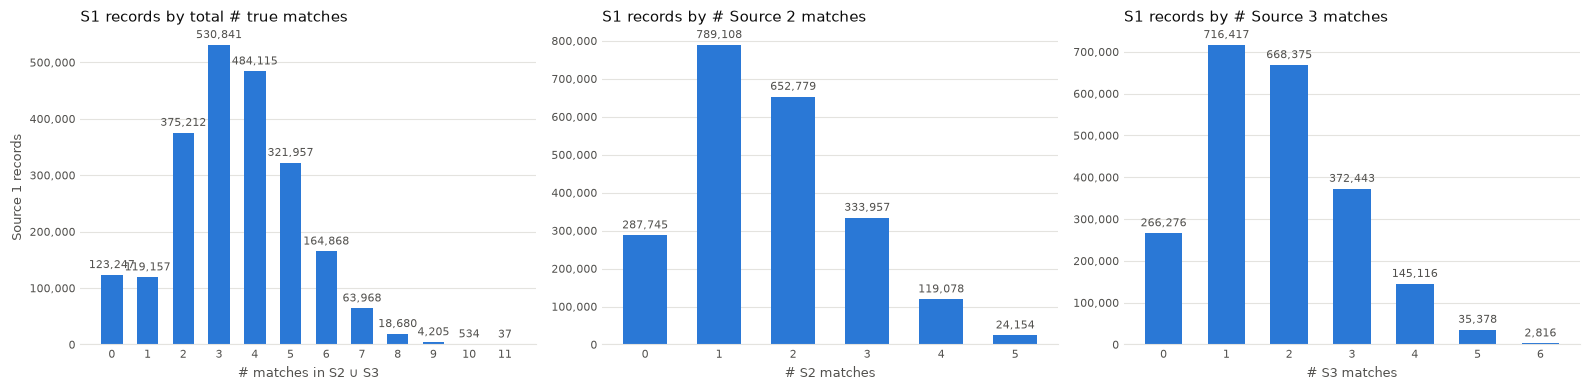

In [19]:
# Histograms: single-series columns, value on cap, recessive axes (one hue, no legend needed)
BLUE, INK, INK2, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df"
def column_chart(ax, cats, vals, title, xlabel):
    bars = ax.bar(cats, vals, color=BLUE, width=0.6, zorder=2)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:,}", (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8, color=INK2)
    ax.set_title(title, loc="left", fontsize=11, color=INK)
    ax.set_xlabel(xlabel, color=INK2, fontsize=9)
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=8, length=0)

s2d = q("SELECT n_s2 k, COUNT(*) n FROM s1_mc GROUP BY 1 ORDER BY 1")
s3d = q("SELECT n_s3 k, COUNT(*) n FROM s1_mc GROUP BY 1 ORDER BY 1")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
column_chart(axes[0], full.match_count.astype(str), full.source1_entity_count, "S1 records by total # true matches", "# matches in S2 ∪ S3")
column_chart(axes[1], s2d.k.astype(str), s2d.n, "S1 records by # Source 2 matches", "# S2 matches")
column_chart(axes[2], s3d.k.astype(str), s3d.n, "S1 records by # Source 3 matches", "# S3 matches")
axes[0].set_ylabel("Source 1 records", color=INK2, fontsize=9)
plt.tight_layout(); plt.show()

### 9.1 Source 2 vs Source 3 matches

In [20]:
by_src = q("""SELECT src, COUNT(*) true_pairs, COUNT(DISTINCT s1_id) s1_entities_with_match FROM pairs GROUP BY 1 ORDER BY 1""")
tot = {"S2": SUMMARY["row_counts"]["Source 2"], "S3": SUMMARY["row_counts"]["Source 3"]}
by_src["source_rows"] = by_src.src.map(tot)
by_src["pct_of_source_rows_matched"] = (100 * by_src.true_pairs / by_src.source_rows).round(2)
by_src["pct_of_all_true_pairs"] = (100 * by_src.true_pairs / by_src.true_pairs.sum()).round(2)
display(by_src)

cat = q("""
SELECT CASE WHEN n_s2=0 AND n_s3=0 THEN 'no matches' WHEN n_s3=0 THEN 'Source 2 only'
            WHEN n_s2=0 THEN 'Source 3 only' ELSE 'both Source 2 and Source 3' END category,
       COUNT(*) source1_entities
FROM s1_mc GROUP BY 1 ORDER BY 2 DESC""")
cat["pct"] = (100 * cat.source1_entities / cat.source1_entities.sum()).round(2)
display(cat)

print("Joint distribution (#S2 matches x #S3 matches), S1 record counts:")
display(q("SELECT n_s2, n_s3, COUNT(*) n FROM s1_mc GROUP BY ALL").pivot(index="n_s2", columns="n_s3", values="n").fillna(0).astype(int))

print("Unmatched records in S2/S3 (belong to no S1 entity in training GT) - these are pure distractors:")
um = q("""SELECT t.src, t.country, COUNT(*) n, COUNT(*) FILTER (WHERE p.match_id IS NULL) unmatched,
                 ROUND(100.0*COUNT(*) FILTER (WHERE p.match_id IS NULL)/COUNT(*),2) pct_unmatched
          FROM et t LEFT JOIN pairs p ON p.match_id = t.entity_id GROUP BY ALL ORDER BY 1,2""", "ground_truth")
display(um)
SUMMARY["s2_s3"] = {"by_source": by_src.to_dict(orient="records"),
                    "s1_categories": dict(zip(cat.category, cat.source1_entities.astype(int))),
                    "unmatched_targets": um.to_dict(orient="records")}

,src,true_pairs,s1_entities_with_match,source_rows,pct_of_source_rows_matched,pct_of_all_true_pairs
0,S2,3693619,1919076,5034616,73.36,48.36
1,S3,3944746,1940545,5285603,74.63,51.64


,category,source1_entities,pct
0,both Source 2 and Source 3,1776047,80.48
1,Source 3 only,164498,7.45
2,Source 2 only,143029,6.48
3,no matches,123247,5.58


Joint distribution (#S2 matches x #S3 matches), S1 record counts:


n_s3,0,1,2,3,4,5,6
n_s2,,,,,,,
0,123247,60407,57041,31526,12260,3017,247
1,58750,269681,251224,140393,54575,13437,1048
2,48490,223054,208159,116076,45167,10957,876
3,25037,114405,105817,59427,23315,5504,452
4,8898,40618,38338,20852,8131,2085,156
5,1854,8252,7796,4169,1668,378,37


Unmatched records in S2/S3 (belong to no S1 entity in training GT) - these are pure distractors:


[ground_truth: 0.3s]


,src,country,n,unmatched,pct_unmatched
0,S2,India,2017799,537254,26.63
1,S2,US,3016817,803743,26.64
2,S3,India,2115547,536249,25.35
3,S3,US,3170056,804608,25.38


### 9.2 Pair view with both sides' fields
This view has 7.6M rows, one per true pair. It is used for recall and similarity work. It is linear in the GT size, so it involves no Cartesian product. It is a view, not stored, to save disk.

In [21]:
x("""CREATE OR REPLACE VIEW pf AS
     SELECT p.s1_id, p.match_id, p.src,
            a.business_name a_name, a.business_address a_addr, a.country a_country, a.name_n a_name_n, a.addr_n a_addr_n, a.name_a a_name_a, a.addr_a a_addr_a,
            b.business_name b_name, b.business_address b_addr, b.country b_country, b.name_n b_name_n, b.addr_n b_addr_n, b.name_a b_name_a, b.addr_a b_addr_a
     FROM pairs p JOIN e1 a ON a.entity_id = p.s1_id JOIN et b ON b.entity_id = p.match_id""", "pair_table")
agree = q("""
SELECT src, COUNT(*) pairs,
  ROUND(100.0*AVG((a_country = b_country)::INT),3)            pct_same_country,
  ROUND(100.0*AVG((a_name = b_name)::INT),2)                  pct_exact_name,
  ROUND(100.0*AVG((a_name_n = b_name_n)::INT),2)              pct_basic_name,
  ROUND(100.0*AVG((a_name_a = b_name_a)::INT),2)              pct_alnum_name,
  ROUND(100.0*AVG((a_addr = b_addr)::INT),2)                  pct_exact_addr,
  ROUND(100.0*AVG((a_addr_n = b_addr_n)::INT),2)              pct_basic_addr,
  ROUND(100.0*AVG((a_addr_a = b_addr_a)::INT),2)              pct_alnum_addr,
  ROUND(100.0*AVG((b_addr IS NULL)::INT),2)                   pct_target_addr_null,
  ROUND(100.0*AVG((a_addr IS NULL)::INT),2)                   pct_s1_addr_null,
  ROUND(100.0*AVG((has_indic(b_name) AND NOT has_indic(a_name))::INT),2) pct_script_mismatch_name
FROM pf GROUP BY 1 ORDER BY 1""", "pair_table")
display(agree)
print("Country disagreement inside true pairs:")
display(q("SELECT a_country, b_country, COUNT(*) n FROM pf WHERE a_country IS DISTINCT FROM b_country GROUP BY ALL ORDER BY n DESC LIMIT 10"))
SUMMARY["true_pair_field_agreement"] = agree.to_dict(orient="records")

[pair_table: 0.0s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[pair_table: 15.5s]


,src,pairs,pct_same_country,pct_exact_name,pct_basic_name,pct_alnum_name,pct_exact_addr,pct_basic_addr,pct_alnum_addr,pct_target_addr_null,pct_s1_addr_null,pct_script_mismatch_name
0,S2,3693619,100.0,4.73,15.64,25.28,0.00,11.22,13.06,4.47,0.0,9.33
1,S3,3944746,100.0,4.55,15.89,26.27,4.51,4.52,4.52,4.36,0.0,5.24


Country disagreement inside true pairs:


,a_country,b_country,n


## 10. Positive Match Examples
There are 20 random Source 1 entities that have at least one match. Each block shows the S1 record followed by all its true S2/S3 records.

In [22]:
ex_ids = q("""SELECT s1_id FROM (SELECT * FROM s1_mc WHERE n_matches > 0) USING SAMPLE reservoir(20 ROWS) REPEATABLE (2026)""").s1_id.tolist()
con.register("ex_ids_df", pd.DataFrame({"s1_id": ex_ids}))
ex = q("""
SELECT s1_id, 0 ord, 'S1' src, s1_id entity_id, a_name business_name, a_addr business_address, a_country country FROM (SELECT DISTINCT s1_id, a_name, a_addr, a_country FROM pf WHERE s1_id IN (SELECT s1_id FROM ex_ids_df))
UNION ALL
SELECT s1_id, CASE src WHEN 'S2' THEN 1 ELSE 2 END, src, match_id, b_name, b_addr, b_country FROM pf WHERE s1_id IN (SELECT s1_id FROM ex_ids_df)
ORDER BY s1_id, ord, entity_id""", "examples")
for i, (sid, g) in enumerate(ex.groupby("s1_id", sort=False), 1):
    print(f"\n── Example {i}: {sid}  ({(g.src!='S1').sum()} matches)")
    display(g[["src", "entity_id", "business_name", "business_address", "country"]].reset_index(drop=True))

[examples: 1.6s]

── Example 1: S1-101793191  (6 matches)


,src,entity_id,business_name,business_address,country
0,S1,S1-101793191,Quus,"1524 60th Avenue, Portland, OR",US
1,S2,S2-264427619,Q5URUS,"1524. 60TH AVE, PORTLAND, OR",US
2,S2,S2-542598109,Quus,"1524. 60TH AVENUE, PORTLAND, OR",US
3,S2,S2-966425267,Qúus,"1524. 60TH AVE, PORTLAND, OR",US
4,S3,S3-214056701,quus,"60nd Avenue, Portlland CITY, Oregon",US
5,S3,S3-381595123,Qúus,"1524 60nd Ave, Portlland CITY, Oregon",US
6,S3,S3-625380527,>> Quus,"1524 60nd Ave, Portlland CITY, Oregon",US



── Example 2: S1-155617539  (3 matches)


,src,entity_id,business_name,business_address,country
0,S1,S1-155617539,Osceola Ave,"54161 Ash Road, Osceola, IN",US
1,S2,S2-825071369,Ocsola Ave,"54161 ASH RD, OSCEOLA, IN",US
2,S3,S3-276856276,OSCEOLA AVE,"54161 Ash Rd, Osceola, Indiana",US
3,S3,S3-859866262,osceolaave.com,"54161 Ash Rd, Osceola, Indiana",US



── Example 3: S1-23525909  (5 matches)


...

,src,entity_id,business_name,business_address,country
0,S1,S1-927223731,Mumbai India Private Limited,"5045, 3Rd Floor, Rustomjee Eaze Zone, Laxmi Singh, Complex, G. M. Link Road, Malad (West), Mumbai, Mumbai ...",India
1,S2,S2-367300405,MUMBAI INIA PRIVATE LIMITED,"D/5045, 3RD FLOOR, RUSTOMJEE EAZE ZONE, LAXMI SINGH, COMPLEX, G. M. LINK ROAD, MALAD (WEST), MUMBAI, महारा...",India
2,S2,S2-375963418,Mumbai India Private-Limited,"D/5045, 3RD FLOOR, RUSTOMJEE EAZE ZONE, LAXMI SINGH, COMPLEX, G. M. LINK ROAD, MALAD (WEST), MUMBAI, Mahar...",India
3,S2,S2-814877962,Mumbai India Private Ltd,"D/5045, 3RD FLOOR, RUSTOMJEE EAZE ZONE, LAXMI SINGH, COMPLEX, G. M. LINK ROAD, MALAD (WEST), MUMBAI, Mahar...",India
4,S2,S2-988963308,MUMBAI INDIA PRIVATE LTD,"Maharashtra, D/5045, 3RD FLOOR, RUSTOMJEE EAZE ZONE, LAXMI SINGH, COMPLEX, G. M. LINK ROAD, MALAD (WEST), ...",India
5,S3,S3-7246768,Calomiraquo doing business as Mumbai India Private Limited,"5045, 3Rd Floor, Rustomjee Eaze Zone, Laxmi Singh, Complex, G. M. Link Road, Malad (West), Mumbai, Mumbai ...",India
6,S3,S3-792132464,Mumbai India Private,"5045, 3Rd Floor, Rustomjee Eaze Zone, Laxmi Singh, Complex, G. M. Link Road, Malad (West), Mumbai, Mumbai ...",India
7,S3,S3-912239510,Mumbai India Private Ltd,"5045, 3Rd Floor, Rustomjee Eaze Zone, Laxmi Singh, Complex, G. M. Link Road, Malad (West), Mumbai, Mumbai ...",India



── Example 19: S1-931484667  (4 matches)


,src,entity_id,business_name,business_address,country
0,S1,S1-931484667,"A Rapid Translational, Corp","11138 5600, Highland, UT",US
1,S2,S2-511629531,"A Rapid Translational, Corporation",NaN,US
2,S3,S3-244934283,"A Rapid Corp Translational,","11138 5600, Ammerican FORK, Utah",US
3,S3,S3-311955571,"A Corp Translational, Rapid","11138 5600, Ammerican FORK, Utah",US
4,S3,S3-596947753,A Rapid,"11138 5600, Ammerican FORK, Utah",US



── Example 20: S1-936054548  (5 matches)


,src,entity_id,business_name,business_address,country
0,S1,S1-936054548,Red Global Private Limited,"Unit-D, Third Floor, A-49, F.I.E.E, Okhla Industrial Area, Phase-Ii, New Delhi, South Delhi, Delhi",India
1,S2,S2-494542676,रेड ग्लोबल प्राइवेट लिमिटेड,"UNIT-D, THIRD FLOOR, A-49, F.I.E.E, OKHLA INDUSTRIAL AREA, PHASE-II, SOUTH AND EAST DELHI, SOUTH DELHI, Delhi",India
2,S2,S2-924989733,रेड ग्लोबल प्राइवेट लिमिटेड,"UNIT-D, SOUTH DELHI, दिल्ली, SOUTH AND EAST DELHI",India
3,S3,S3-268620549,Red Global Private Ltd,NaN,India
4,S3,S3-548849090,Red Global,"Unit-D, Third Floor, A-49, F.I.E.E, Okhla Industrial Area, Phase-Ii, New Delhi, South Delhi, Delhi",India
5,S3,S3-88422470,Red Global Private,"Unit-d, New Delhi, South East Delhi, DL",India


### 10.1 Difficult Positive Matches (RapidFuzz on a 100k sample of true pairs)
Similarity is computed on the **basic-normalised** strings. `token_sort_ratio` tolerates word order. `ratio` is plain edit similarity. A missing field gets a similarity of NaN and is counted as "missing".

In [23]:
t = time.time()
# sample the small ID-only pair table first, then join just those 100k rows (sampling the pf view would materialise 7.6M joined rows)
smp = q("""
WITH sp AS (SELECT * FROM pairs USING SAMPLE reservoir(100000 ROWS) REPEATABLE (42))
SELECT sp.s1_id, sp.match_id, sp.src,
       a.business_name a_name, a.business_address a_addr, a.country a_country, a.name_n a_name_n, a.addr_n a_addr_n,
       norm_alnum(a.business_name) a_name_a, norm_alnum(a.business_address) a_addr_a,
       b.business_name b_name, b.business_address b_addr, b.country b_country, b.name_n b_name_n, b.addr_n b_addr_n,
       norm_alnum(b.business_name) b_name_a, norm_alnum(b.business_address) b_addr_a
FROM sp JOIN r1 a ON a.entity_id = sp.s1_id
JOIN (SELECT * FROM r2 UNION ALL SELECT * FROM r3) b ON b.entity_id = sp.match_id""", "hard_positives")
def sim(a, b, scorer):
    a = a.fillna("").tolist(); b = b.fillna("").tolist()
    return cpdist(a, b, scorer=scorer, workers=-1)
smp["name_tsr"] = sim(smp.a_name_n, smp.b_name_n, fuzz.token_sort_ratio)
smp["name_ratio"] = sim(smp.a_name_n, smp.b_name_n, fuzz.ratio)
smp["name_tset"] = sim(smp.a_name_n, smp.b_name_n, fuzz.token_set_ratio)
smp["addr_tsr"] = sim(smp.a_addr_n, smp.b_addr_n, fuzz.token_sort_ratio)
smp["addr_tset"] = sim(smp.a_addr_n, smp.b_addr_n, fuzz.token_set_ratio)
for c in ["addr_tsr", "addr_tset"]:
    smp.loc[smp.a_addr_n.isna() | smp.b_addr_n.isna(), c] = np.nan
for c in ["name_tsr", "name_ratio", "name_tset"]:
    smp.loc[smp.a_name_n.isna() | smp.b_name_n.isna(), c] = np.nan
smp["script_mismatch"] = smp.b_name.fillna("").str.contains(r"[ऀ-෿]") != smp.a_name.fillna("").str.contains(r"[ऀ-෿]")

# token overlap diagnostics (alnum tokens)
tok = lambda s: set(s.split()) if isinstance(s, str) else set()
smp["name_shared_tokens"] = [len(tok(a) & tok(b)) for a, b in zip(smp.a_name_a, smp.b_name_a)]
smp["addr_shared_tokens"] = [len(tok(a) & tok(b)) for a, b in zip(smp.a_addr_a, smp.b_addr_a)]
num = lambda s: set(re.findall(r"\d+", s)) if isinstance(s, str) else set()
smp["addr_shared_numbers"] = [len({n.lstrip('0') for n in num(a)} & {n.lstrip('0') for n in num(b)}) for a, b in zip(smp.a_addr, smp.b_addr)]
TIMINGS["hard_positives"] = round(TIMINGS.get("hard_positives", 0) + time.time() - t, 2)
print(f"similarities on {len(smp):,} pairs in {time.time()-t:.1f}s")

desc = smp.groupby("src")[["name_tsr", "name_ratio", "name_tset", "addr_tsr", "addr_tset"]].describe(percentiles=[.01, .05, .1, .25, .5]).T
display(desc.round(1))

[hard_positives: 1.5s]


similarities on 100,000 pairs in 2.7s


src                    S2       S3
name_tsr   count  48244.0  51756.0
           mean      77.0     78.5
           std       26.7     23.7
           min        3.8      0.0
           1%         8.0      8.6
           5%         9.8     15.4
           10%       25.0     45.5
           25%       69.0     70.0
           50%       87.2     86.3
           max      100.0    100.0
name_ratio count  48244.0  51756.0
           mean      77.8     79.4
           std       25.9     22.6
           min        3.8      0.0
           1%         8.0      8.6
           5%         9.8     16.0
           10%       25.0     52.6
           25%       71.6     72.0
           50%       87.0     86.4
           max      100.0    100.0
name_tset  count  48244.0  51756.0
           mean      83.0     86.2
           std       27.6     23.8
           min        0.0      0.0
           1%         8.0      8.6
           5%         9.8     15.8
           10%       25.6     51.9
           25%       82.1     85.1
           50%       95.7     96.6
           max      100.0    100.0
addr_tsr   count  46056.0  49525.0
           mean      87.8     80.7
           std       11.8     15.1
           min       15.4     10.7
           1%        46.6     33.0
           5%        63.6     47.1
           10%       72.1     58.3
           25%       82.5     75.3
           50%       91.0     84.6
           max      100.0    100.0
addr_tset  count  46056.0  49525.0
           mean      92.0     86.4
           std        8.9     10.8
           min       19.6     12.7
           1%        60.7     50.8
           5%        73.7     64.9
           10%       80.0     72.0
           25%       88.5     81.4
           50%       94.3     88.6
           max      100.0    100.0

In [24]:
def pct(mask): return round(100 * mask.mean(), 2)
hp = {}
for s, g in list(smp.groupby("src")) + [("all", smp)]:
    hp[s] = {
        "n": len(g),
        "name_tsr_lt_50": pct(g.name_tsr < 50), "name_tsr_lt_70": pct(g.name_tsr < 70), "name_tsr_eq_100": pct(g.name_tsr == 100),
        "addr_tsr_lt_50": pct(g.addr_tsr < 50), "addr_tsr_lt_70": pct(g.addr_tsr < 70),
        "addr_missing_either": pct(g.addr_tsr.isna()),
        "script_mismatch_name": pct(g.script_mismatch),
        "no_shared_name_token": pct(g.name_shared_tokens == 0),
        "no_shared_addr_token": pct((g.addr_shared_tokens == 0) & g.addr_tsr.notna()),
        "no_shared_addr_number": pct((g.addr_shared_numbers == 0) & g.addr_tsr.notna()),
        "no_shared_name_AND_addr_token": pct((g.name_shared_tokens == 0) & (g.addr_shared_tokens == 0)),
        "name_lt50_and_addr_lt50_or_missing": pct((g.name_tsr < 50) & ((g.addr_tsr < 50) | g.addr_tsr.isna())),
    }
hp = pd.DataFrame(hp)
display(hp.rename_axis("% of sampled true pairs"))
SUMMARY["hard_positives_sample"] = hp.to_dict()

,S2,S3,all
% of sampled true pairs,,,
n,48244.00,51756.00,100000.00
name_tsr_lt_50,13.78,11.36,12.53
name_tsr_lt_70,25.70,24.97,25.32
name_tsr_eq_100,19.59,20.11,19.86
addr_tsr_lt_50,1.35,5.78,3.64
addr_tsr_lt_70,7.97,17.32,12.81
addr_missing_either,4.54,4.31,4.42
script_mismatch_name,9.39,5.11,7.17
no_shared_name_token,16.08,12.56,14.26


In [25]:
cols = ["src", "s1_id", "match_id", "a_name", "b_name", "name_tsr", "a_addr", "b_addr", "addr_tsr"]
rng = 7
def pick(mask, n):
    g = smp[mask]
    return g.sample(min(n, len(g)), random_state=rng)[cols]
groups = {
    "Low name similarity, same script (name_tsr < 45)":         (smp.name_tsr < 45) & ~smp.script_mismatch,
    "Transliteration / script mismatch (Indic vs Latin)":        smp.script_mismatch,
    "Low address similarity (addr_tsr < 45)":                    smp.addr_tsr < 45,
    "Address missing on one side":                               smp.addr_tsr.isna(),
    "Both name and address weak (<60 or missing)":               (smp.name_tsr < 60) & ((smp.addr_tsr < 60) | smp.addr_tsr.isna()),
}
hard_examples = []
for title, m in groups.items():
    print(f"\n### {title}  — {m.sum():,} of {len(smp):,} sampled pairs ({100*m.mean():.2f}%)")
    d = pick(m, 4); hard_examples.append(d.assign(category=title)); display(d.reset_index(drop=True))


### Low name similarity, same script (name_tsr < 45)  — 4,188 of 100,000 sampled pairs (4.19%)


,src,s1_id,match_id,a_name,b_name,name_tsr,a_addr,b_addr,addr_tsr
0,S3,S1-52104898,S3-800275451,Smith Colonial Virtus PLLC,Smith,32.258064,"1688 Broadway Avenue, Niles, OH","1688 Broadway Avenue, Niles, OH",100.000000
1,S2,S1-45408880,S2-694988364,Pasha It Private Limited,Pasha Ít,43.750000,"No:21/A, Yagappa Nagar, Thanjavur, Tamil Nadu","NO:#21/A, YAGAPPA NAGAR, THANJAVUR, Tamil Nadu",98.901100
2,S3,S1-128377375,S3-175441642,"Haynes Grading, LLC",@haynesgrading,42.424244,"2208 Samish Way, Bellingham, WA","2208 Samish Way, Bellingham, Washington",88.571426
3,S3,S1-314860506,S3-804839244,Ram Industries Limited,Synyuma Co,25.000000,"Flat No.195 Cat Iii Dda Pkt B East Of Kailash, Delhi, North East, Delhi","Flat No.195 Cat Iii Dda Pkt B East Of Kailash, Delhi, North East, Delhi",100.000000



### Transliteration / script mismatch (Indic vs Latin)  — 7,173 of 100,000 sampled pairs (7.17%)


,src,s1_id,match_id,a_name,b_name,name_tsr,a_addr,b_addr,addr_tsr
0,S2,S1-360529355,S2-658667282,Shiv Enterprises Private Limited,Shiv എന്റർപ്രൈസസ് പ്രൈവറ്റ് ലിമിറ്റഡ്,11.594203,"162-A, Mundanat, Ambadi Chelakkara Road, Cheruthuruthy, Thrissur, Kerala","162-A, MUNDANAT, AMBADI CHELAKKARA ROAD, CHERUTHURUTHY, THRISSUR, Kerala",100.000000
1,S3,S1-683358777,S3-444610155,First Gold Infra Private Limited,ফার্স্ট গোল্ড ইনফ্রা প্রাইভেট লিমিটেড,11.594203,"71 Metcalfe Street 3Rd Floor, Room No. 308, Kolkata, Kolkata, Howrah, West Bengal","Door No 71 Metcalfe Street 3Rd Floor, Digha Via Dattapukur Dist 24 North Pargana, Howrah, WB",55.491329
2,S3,S1-530420810,S3-137246909,Blue Management Private Limited,ब्लू मैनेजमेंट प्राइवेट लिमिटेड,9.677420,"Shri Krishna Kripa E-15, Shri Ji Velly, Bicholi Mardana, Indore, Madhya Pradesh, Flat No.303","No B3/303, Indore, MP",26.548672
3,S3,S1-206848259,S3-53690993,Red Construction Limited,Red कंस्ट्रक्शन लिमिटेड,17.021276,"Delhi, Central Delhi, 67 Dsidc Complexmata Sundri Road, New Delhi","Central Delhi, दिल्ली, No 67 Dsidc Complexmata Sundri Road, Mumbai",76.335876



### Low address similarity (addr_tsr < 45)  — 2,460 of 100,000 sampled pairs (2.46%)


,src,s1_id,match_id,a_name,b_name,name_tsr,a_addr,b_addr,addr_tsr
0,S2,S1-398313808,S2-249419098,Swastik Marketing Private Limited,स्वस्तिक मार्केटिंग प्राइवेट लिमिटेड,8.695652,"401/02, 434, Floor-4, Bussa Udyog Bhavan Tokersey Jivraj Rd, Sewree Fish Market, Mumbai, Mumbai City, Maha...","401/02, BOMBAY, JASAI, Maharashtra",38.095238
1,S3,S1-84024443,S3-305596714,Rivaan Retailers Company,Smt Rivaan Reaiies Company,84.000000,"Pno 119, E.V.P Prabhu Avenue 8Th Street Koluthuvanchery, Chennai, Tamil Nadu","Pno 119, Chennai, TN",39.583332
2,S2,S1-385149512,S2-618606856,Silver Power Private Limited,सिल्वर पावर प्राइवेट लिमिटेड,10.714286,"395, Kalika Kunj, Motivihar Silokhra, Opp. Block C, South City 1, Gurgaon, Haryana","395, GURGAON, Haryana",40.776699
3,S3,S1-91882179,S3-279567691,Solutions Indo Care Private Limited,Private Solutions Indo Care Limited,100.000000,"501, Floor/5, 14, Doctor House Dr Gopalrao Deshmukh Marg, Cumballa Hill, Mumbai, Mumbai City, Maharashtra","501, Mumbai City, Mumbai, MH",42.105263



### Address missing on one side  — 4,419 of 100,000 sampled pairs (4.42%)


,src,s1_id,match_id,a_name,b_name,name_tsr,a_addr,b_addr,addr_tsr
0,S2,S1-607944389,S2-959208684,Downtown Ice Cream,Downtown Ice Cream Ltd,90.000000,"371 Walnut Street, St Henry, OH",NaN,NaN
1,S3,S1-744454166,S3-462589568,Green Pioneer Constellation Inc,Green Pioneer Inc Constellation,100.000000,"1384 Clay 131 Road, Corning, AR",NaN,NaN
2,S2,S1-281004718,S2-233989788,"Baldwin, Delphinia, M.D. Partners","Baldwin, Delphinia, M.D. Pártners",96.969696,"125 Warner Hill Road, Unit Unit 29, Stratford, CT",NaN,NaN
3,S3,S1-829963152,S3-928775992,Bangalore Apparels Private Limited,Bangalore Apparels Private,86.666664,"Karnataka, Bangalore, 61St Cross 5Th Block Rajajinagar, No 683, Bangalore",NaN,NaN



### Both name and address weak (<60 or missing)  — 2,250 of 100,000 sampled pairs (2.25%)


,src,s1_id,match_id,a_name,b_name,name_tsr,a_addr,b_addr,addr_tsr
0,S3,S1-513186773,S3-858451573,Good Logistics Pvt Ltd,गुड Logistics प्रा. लि.,48.888889,"Plot No Rc1/2, Tower No S2, Office No 5A56, 6Th Floor, Cloud 9, Sector 1, Vaishali, Ghaziabad, Uttar Pradesh","Ghaziabad, UP, Ghaziabad, Plt No Rc1/2",41.095890
1,S2,S1-290353753,S2-278158635,Classic Impex Private Limited,ക്ലാസിക് ഇംപെക്സ് പ്രൈവറ്റ് ലിമിറ്റഡ്,9.090909,"Room No. 10/124 O, Reliable Arcade, Amala Nagar, Adat Grama Panchayat, Thrissur, Kerala","ROOM NO. 0/124 O, THRISSUR, Keralam",55.737705
2,S3,S1-313132464,S3-461614210,Odell Intelligence PC,Odell PC Service,43.243244,"30925 363rd Avenue, Arlington, WA",NaN,NaN
3,S3,S1-846320271,S3-10757388,Gold One Consultants Private Limited,கோல்டு ஒன் கன்சல்டன்ட்ஸ் பிரைவேட் லிமிடெட்,10.256411,"2/4, Manikandan Mudali St, 2Nd Lane Manikanda Mudali 2Ndlane Oldwashermenpet, Chennai, Tamil Nadu","2/4, N/A, Chennai, TN",32.203388


## 11. Potential Hard Negatives
These pairs are found only through exact blocking keys, with no random all-pairs comparison.

Labels:
* **GT non-match (target belongs to a different S1 entity).** The training GT assigns the target record to another S1 entity. Because GT clusters are disjoint (no target ID appears twice), this pair is a non-match **according to training labels**.
* **Potential hard negative / needs verification.** The target is not matched to *any* S1 record in the GT, or the pair is S1↔S1. It is very likely a non-match, but that has not been demonstrated.

In [26]:
def collision_counts(key_a, key_b, label):
    """Aggregation-only counts of non-true pairs sharing an exact key, split by label type."""
    r = q(f"""
    WITH a AS (SELECT {key_a} k, COUNT(*) n1 FROM e1 WHERE {key_a} IS NOT NULL GROUP BY 1),
         b AS (SELECT {key_b} k, COUNT(*) n2,
                      COUNT(*) FILTER (WHERE p.match_id IS NOT NULL) n2_matched,
                      COUNT(*) FILTER (WHERE p.match_id IS NULL)     n2_unmatched
               FROM et LEFT JOIN pairs p ON p.match_id = et.entity_id WHERE {key_b} IS NOT NULL GROUP BY 1),
         tp AS (SELECT COUNT(*) n FROM pf WHERE {key_a.replace('name_n','a_name_n').replace('addr_n','a_addr_n').replace('country','a_country')}
                                          = {key_b.replace('name_n','b_name_n').replace('addr_n','b_addr_n').replace('country','b_country')})
    SELECT SUM(n1*n2) candidates, (SELECT n FROM tp) true_pairs_retrieved,
           SUM(n1*n2_matched) - (SELECT n FROM tp) AS gt_nonmatch_target_in_other_entity,
           SUM(n1*n2_unmatched) AS potential_target_unmatched_in_gt
    FROM a JOIN b USING (k)""", "hard_negatives").iloc[0]
    return {"key": label, **{k: int(v) for k, v in r.items()}}

s1s1 = lambda key: int(q(f"SELECT COALESCE(SUM(n*(n-1)/2),0) FROM (SELECT COUNT(*) n FROM e1 WHERE {key} IS NOT NULL GROUP BY {key})").iloc[0, 0])
hn = pd.DataFrame([
    collision_counts("name_n", "name_n", "same basic-normalised name"),
    collision_counts("addr_n", "addr_n", "same basic-normalised address"),
    collision_counts("name_n || '|' || country", "name_n || '|' || country", "same name + country"),
])
hn["s1_s1_pairs_same_key (potential)"] = [s1s1("name_n"), s1s1("addr_n"), s1s1("name_n || '|' || country")]
hn["pct_candidates_that_are_true"] = (100 * hn.true_pairs_retrieved / hn.candidates).round(2)
display(hn)
SUMMARY["hard_negative_counts"] = hn.to_dict(orient="records")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[hard_negatives: 4.3s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[hard_negatives: 2.6s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[hard_negatives: 4.5s]


,key,candidates,true_pairs_retrieved,gt_nonmatch_target_in_other_entity,potential_target_unmatched_in_gt,s1_s1_pairs_same_key (potential),pct_candidates_that_are_true
0,same basic-normalised name,15852539,1204650,13337359,1310530,8190493,7.60
1,same basic-normalised address,690250,566260,117466,6524,153051,82.04
2,same name + country,15793889,1204650,13281358,1307881,8182366,7.63


In [27]:
# Examples: same normalised name, different entity (low-multiplicity keys so the join is tiny)
x("""CREATE OR REPLACE TEMP TABLE hn_keys AS
     WITH a AS (SELECT name_n k, COUNT(*) n1 FROM e1 WHERE name_n IS NOT NULL GROUP BY 1 HAVING COUNT(*) <= 2),
          b AS (SELECT name_n k, COUNT(*) n2 FROM et WHERE name_n IS NOT NULL GROUP BY 1 HAVING COUNT(*) BETWEEN 2 AND 8)
     SELECT k FROM a JOIN b USING (k)""", "hard_negatives")
x("""CREATE OR REPLACE TEMP TABLE hn_pairs AS
     SELECT a.entity_id s1_id, a.business_name a_name, a.business_address a_addr, a.country a_country,
            b.src, b.entity_id tgt_id, b.business_name b_name, b.business_address b_addr, b.country b_country,
            p.s1_id AS tgt_true_s1
     FROM (SELECT * FROM e1 WHERE name_n IN (SELECT k FROM hn_keys)) a
     JOIN (SELECT * FROM et WHERE name_n IN (SELECT k FROM hn_keys)) b ON a.name_n = b.name_n
     LEFT JOIN pairs p ON p.match_id = b.entity_id
     WHERE p.s1_id IS DISTINCT FROM a.entity_id""", "hard_negatives")
print("candidate non-true pairs from sampled low-multiplicity name keys:", con.execute("SELECT COUNT(*) FROM hn_pairs").fetchone()[0])
hn_s = q("SELECT * FROM hn_pairs USING SAMPLE reservoir(20000 ROWS) REPEATABLE (3)")
hn_s["addr_tsr"] = cpdist(hn_s.a_addr.fillna("").str.lower().tolist(), hn_s.b_addr.fillna("").str.lower().tolist(), scorer=fuzz.token_sort_ratio, workers=-1)
hn_s.loc[hn_s.a_addr.isna() | hn_s.b_addr.isna(), "addr_tsr"] = np.nan
hn_s["label"] = np.where(hn_s.tgt_true_s1.notna(), "GT non-match (target belongs to " + hn_s.tgt_true_s1.fillna("") + ")",
                         "Potential hard negative / needs verification")
print("addr similarity of same-name non-true pairs:")
display(hn_s.addr_tsr.describe(percentiles=[.1, .25, .5, .75, .9]).round(1).to_frame().T)
show_cols = ["label", "s1_id", "a_name", "a_addr", "src", "tgt_id", "b_name", "b_addr", "addr_tsr"]
print("\n### Same name, DIFFERENT address (chains / common names)")
display(hn_s[hn_s.addr_tsr < 40].sample(min(6, (hn_s.addr_tsr < 40).sum()), random_state=1)[show_cols].reset_index(drop=True))
print("\n### Same name AND similar address, yet not a GT match — most dangerous")
display(hn_s[hn_s.addr_tsr >= 75].sample(min(8, (hn_s.addr_tsr >= 75).sum()), random_state=1)[show_cols].reset_index(drop=True))
SUMMARY["hard_negative_same_name_sample"] = {
    "n_sampled": len(hn_s), "addr_tsr_median": float(hn_s.addr_tsr.median()),
    "pct_addr_tsr_ge_75": round(100 * (hn_s.addr_tsr >= 75).mean(), 2),
    "pct_gt_labelled_nonmatch": round(100 * hn_s.tgt_true_s1.notna().mean(), 2)}

[hard_negatives: 0.6s]


[hard_negatives: 1.2s]
candidate non-true pairs from sampled low-multiplicity name keys: 203430
addr similarity of same-name non-true pairs:


,count,mean,std,min,10%,25%,50%,75%,90%,max
addr_tsr,19082.0,36.5,6.1,12.5,29.6,32.7,36.1,40.0,43.8,97.4



### Same name, DIFFERENT address (chains / common names)


,label,s1_id,a_name,a_addr,src,tgt_id,b_name,b_addr,addr_tsr
0,GT non-match (target belongs to S1-468399057),S1-936941723,Angelia's Premier Chemical,"1571 Anglin Mill Road, Stoneville, NC",S2,S2-310422626,Angelia's Premier Chemical,"WINGINA, 1002 MAYO CREK LN, VA",35.820896
1,Potential hard negative / needs verification,S1-320911784,Highland Program LLC,"223 Blackman Road, Unit A, Nashville, TN",S2,S2-902886260,HIGHLAND PROGRAM LLC,"21659 62, SHADY COVEC DP, OR",35.294117
2,Potential hard negative / needs verification,S1-234673985,Tri-State School of Medicine Inc,"Chelmsford, MA, 32 Grandview Road",S3,S3-288526520,Tri-State School of Medicine Inc,"17 State Rd, Westminster, Massachusetts",38.888889
3,GT non-match (target belongs to S1-664642091),S1-990369012,Urgent Care Capital Medicine,"17340 Sargent Road, Unit 24, Rochester, WA",S2,S2-191787466,Urgent Care Capital Medicine,"1805. REVERE PLACE, CARMEL, IN",36.111111
4,Potential hard negative / needs verification,S1-988516196,Bright Pub!,"1455 Thompson Road, Woodburn, OR",S2,S2-743366088,Bright Pub!,"10227 KOMENSKY AVENUE, OAK LAWN, IL",35.820896
5,GT non-match (target belongs to S1-923008637),S1-304120780,Lutz Kgaa,"VA, 231 Winter Hawk Road, Henry County",S2,S2-113398599,LUTZ KGAA,"450 HANGAR AVENUE, CHICOPEE TOWNSHIP, MA",33.333332



### Same name AND similar address, yet not a GT match — most dangerous


,label,s1_id,a_name,a_addr,src,tgt_id,b_name,b_addr,addr_tsr
0,GT non-match (target belongs to S1-618071528),S1-508074666,Delhi Interior Pvt. Ltd.,"100, Okhla Industrial Area Phase - Iii, Delhi, South Delhi, Delhi",S2,S2-70403177,Delhi Interior Pvt. Ltd.,"E-43/ OKHLA INDUSTRIAL AREA PHASE - II, DELHI, Delhi",82.051285
1,Potential hard negative / needs verification,S1-81689918,Davis Colonial Infrastructure Inc.,"Trafford, 177 S Blount Parkway, AL",S2,S2-910204022,Davis Colonial Infrastructure Inc.,"TRAFFORD, 180 S BLOUNT PKWY, AL",89.230766
2,Potential hard negative / needs verification,S1-853991992,Allen Platinum Pony Group,"5058 154th Street, Omaha, NE",S2,S2-351652818,Allen Platinum Pony Group,"5061 154TH ST, OMAHA, NE",84.615387
3,Potential hard negative / needs verification,S1-19888653,Liia Group,"21 Oriole Drive, Chicopee, MA",S2,S2-36299525,Liia Group,"22 ORIOLE DRIVE, CHICOPEE, MA",96.551727
4,Potential hard negative / needs verification,S1-92504964,"Davies's Summit Recruiting, L.L.C.","2020 Palomas Drive, Albuquerque, NM",S2,S2-506957446,"Davies's Summit Recruiting, L.L.C.","2027 PALOMAS DR, ALBUQUERQUE, NM",92.537315
5,Potential hard negative / needs verification,S1-839466134,Cantu Holdings,"4170 Allistair Road, Winston-salem, NC",S2,S2-298113321,Cantu Holdings,"4173 ALLISTAIR ROAD, WINSTON-SALEM, NC",97.368423
6,Potential hard negative / needs verification,S1-412354235,Sehra Group of Companies Center,"Block No.154, R.S. 189/1, Village: Dhamdod, Ta. Mangrol, Dist. Surat, Surat, Gujarat",S2,S2-179344464,Sehra Group of Companies Center,"ગુજરાત, BLOCK NO.156, R.S. 189/1, VILLAGE: DHAMDOD, TA. MANGROL, DIST. SURAT, SURAT",88.622757
7,Potential hard negative / needs verification,S1-567226510,"Hernandez, Reed and Cooper, Inc.","1149 Oklahoma Dr, Ames, IA",S2,S2-402355751,"Hernandez, Reed and Cooper, Inc.","1156 OKLAHOMA DR, AMES, IA",92.307693


In [28]:
print("### Same basic-normalised ADDRESS, different entity (sampled, low-multiplicity address keys)")
ha = q("""
WITH k AS (SELECT * FROM (
  SELECT k FROM (SELECT addr_n k FROM e1 WHERE addr_n IS NOT NULL GROUP BY 1 HAVING COUNT(*) = 1)
  JOIN (SELECT addr_n k FROM et WHERE addr_n IS NOT NULL GROUP BY 1 HAVING COUNT(*) BETWEEN 2 AND 6) USING (k)
  ) USING SAMPLE reservoir(3000 ROWS) REPEATABLE (5))
SELECT CASE WHEN p.s1_id IS NOT NULL THEN 'GT non-match (target belongs to ' || p.s1_id || ')'
            ELSE 'Potential hard negative / needs verification' END AS label,
       a.entity_id s1_id, a.business_name a_name, a.business_address a_addr, b.src, b.entity_id tgt_id, b.business_name b_name, b.business_address b_addr
FROM (SELECT * FROM e1 WHERE addr_n IN (SELECT k FROM k)) a
JOIN (SELECT * FROM et WHERE addr_n IN (SELECT k FROM k)) b ON a.addr_n = b.addr_n
LEFT JOIN pairs p ON p.match_id = b.entity_id
WHERE p.s1_id IS DISTINCT FROM a.entity_id""", "hard_negatives")
ha["name_tsr"] = cpdist(ha.a_name.fillna("").str.lower().tolist(), ha.b_name.fillna("").str.lower().tolist(), scorer=fuzz.token_sort_ratio, workers=-1)
print(f"{len(ha):,} non-true same-address pairs in sample; name similarity:")
display(ha.name_tsr.describe(percentiles=[.1, .5, .9]).round(1).to_frame().T)
display(ha.sort_values("name_tsr", ascending=False).head(6).reset_index(drop=True))
display(ha.sample(min(4, len(ha)), random_state=2).reset_index(drop=True))

print("\n### S1 ↔ S1 same basic-normalised name (distinct S1 entities by construction)")
display(q("""
WITH k AS (SELECT * FROM (SELECT name_n FROM e1 WHERE name_n IS NOT NULL GROUP BY 1 HAVING COUNT(*) = 2) USING SAMPLE reservoir(5 ROWS) REPEATABLE (9))
SELECT 'Potential hard negative / needs verification' AS label, entity_id, business_name, business_address, country
FROM e1 WHERE name_n IN (SELECT name_n FROM k) ORDER BY name_n"""))

### Same basic-normalised ADDRESS, different entity (sampled, low-multiplicity address keys)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[hard_negatives: 2.3s]
127 non-true same-address pairs in sample; name similarity:


,count,mean,std,min,10%,50%,90%,max
name_tsr,127.0,51.0,25.4,6.9,23.3,44.1,88.6,97.3


,label,s1_id,a_name,a_addr,src,tgt_id,b_name,b_addr,name_tsr
0,Potential hard negative / needs verification,S1-317699291,IVG Health Pvt Ltd,"No.17 New Colony Virugambakkam Alwarthirunagar, Chennai, Tamil Nadu",S2,S2-992579891,IVGF Health Ltd Pvt,"NO.17 NEW COLONY VIRUGAMBAKKAM ALWARTHIRUNAGAR, CHENNAI, Tamil Nadu",97.297295
1,Potential hard negative / needs verification,S1-657633742,"Joe, Lia H., DMD","333 County Road 1050, Lampasas, TX",S2,S2-966391823,"JOE, LIA DD H.,","333 COUNTY ROAD 1050, LAMPASAS, TX",96.774193
2,Potential hard negative / needs verification,S1-515921647,FC Square Ltd,"S4 E-35 Lajpat Nagar, Ghaziabad, Uttar Pradesh",S2,S2-997350640,FDC Square Ltd,"S4 E-35 LAJPAT NAGAR, GHAZIABAD, Uttar Pradesh",96.296295
3,Potential hard negative / needs verification,S1-962874463,Kritansh Power Limited,"Tower-3, Flat No-184, Pebble Bay, 1St Main Road, Rmv 2Nd Stage, Nti Layout, Bangalore, Karnataka",S2,S2-228818885,Critansh Power Limited,"TOWER-3, FLAT NO-184, PEBBLE BAY, 1ST MAIN ROAD, RMV 2ND STAGE, NTI LAYOUT, BANGALORE, Karnataka",95.454544
4,Potential hard negative / needs verification,S1-588180059,Jarleus Planet Inc,"1449 Cassidy Creek Road, Carlisle, KY",S2,S2-626340489,Inc Jarleuz Planet,"1449 CASSIDY CREEK ROAD, CARLISLE, KY",94.444443
5,Potential hard negative / needs verification,S1-201563305,Aurova Maintenance Corp,"14217 109th Avenue Court, Puyallup, WA",S2,S2-41703078,Auroari Maintenance Corp,"14217 109TH AVENUE COURT, PUYALLUP, WA",93.617020


,label,s1_id,a_name,a_addr,src,tgt_id,b_name,b_addr,name_tsr
0,Potential hard negative / needs verification,S1-708388374,Tejora Mills Limited,"Shop No. 8, Mythri Complex Near Ksrtc Bus Stand, Udupi, Karnataka",S2,S2-264035514,Tejotis Mills Ltd #45025,"SHOP NO. 8, MYTHRI COMPLEX NEAR KSRTC BUS STAND, UDUPI, Karnataka",63.636364
1,Potential hard negative / needs verification,S1-743509942,"Schamber, Garcia & Alves Century","4765 87, Fayetteville, NC",S2,S2-412212742,"Breen, Garcia & Alves","4765 87, FAYETTEVILLE, NC",64.150940
2,GT non-match (target belongs to S1-949062785),S1-165168842,BM Infraventures Pvt. Ltd.,"Goldwin Ferro Alloys Pvt Ltd, Plot No. 129 & 130, Mundargi 2Nd Stage, Bellary, Karnataka",S2,S2-367372524,ಲೋಟಸ್ ಇಂಪೆಕ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"GOLDWIN FERRO ALLOYS PVT LTD, PLOT NO. 129 & 130, MUNDARGI 2ND STAGE, BELLARY, Karnataka",10.344828
3,GT non-match (target belongs to S1-949062785),S1-165168842,BM Infraventures Pvt. Ltd.,"Goldwin Ferro Alloys Pvt Ltd, Plot No. 129 & 130, Mundargi 2Nd Stage, Bellary, Karnataka",S2,S2-580876755,ಲೋಟಸ್ ಇಂಪೆಕ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"GOLDWIN FERRO ALLOYS PVT LTD, PLOT NO. 129 & 130, MUNDARGI 2ND STAGE, BELLARY, Karnataka",10.344828



### S1 ↔ S1 same basic-normalised name (distinct S1 entities by construction)


,label,entity_id,business_name,business_address,country
0,Potential hard negative / needs verification,S1-820051265,Avni Traders Private Limited,"Delhi, 516, 517, 518 Osian Building, 12-Nehru Place, South Delhi, New Delhi",India
1,Potential hard negative / needs verification,S1-662285539,Avni Traders Private Limited,"4-32-300, Flat No 301, Shapur Nagar, Qutubullapur, Tirumalagiri, Hyderabad, Telangana",India
2,Potential hard negative / needs verification,S1-916397639,Dynamic Agro Pvt Ltd,"Flat No. 534, Seven Heaven Appt, H No. 53, Csr No. 8315/1, Rly Lines, Solapur, Maharashtra",India
3,Potential hard negative / needs verification,S1-160770856,Dynamic Agro Pvt Ltd,"No.51/22 T L V Soundarya Flats F2 Kavarai Street, West Saidapet, Chennai, Tamil Nadu",India
4,Potential hard negative / needs verification,S1-965217752,Industries Peacock Logistics Ltd,"H. No 6-3-1112/K/6, White Diamond Apartments, Secunderabad, Hyderabad, Telangana",India
5,Potential hard negative / needs verification,S1-967900610,Industries Peacock Logistics Ltd,"2-Q-24, R.C.Vyas Colony, Bhilwara, Rajasthan",India
6,Potential hard negative / needs verification,S1-686460476,Varshita India Pvt Ltd,"3973, 17Th E Cross, 3Rd Main Bsk 2Nd Stage, Bangalore South, Bangalore, Karnataka",India
7,Potential hard negative / needs verification,S1-593984646,Varshita India Pvt Ltd,"Officeno.302, Raheja Xion, 7A Dr. B.A.Rd, Opp Byculla Goods Depot, Behind Police Comm. Office, Byculla(E),...",India
8,Potential hard negative / needs verification,S1-364597914,"Wynnie Thompson Midwest Limited, PLLC","Prairie Grove, 10892 Hwy 170, AR",US
9,Potential hard negative / needs verification,S1-984061519,"Wynnie Thompson Midwest Limited, PLLC","Conklin, Unit Apartment 1, NY, 667 Conklin Road",US


### 11.1 Are the unmatched S2/S3 records decoys?
About 26% of S2/S3 records match no S1 entity. This cell checks whether they look like real near-copies of S1 entities (hard negatives by design) or unrelated businesses. It compares matched vs unmatched targets on how often their normalised name or address exactly equals some S1 record's.

In [29]:
decoy = q("""
WITH n1 AS (SELECT DISTINCT name_n k FROM r1), a1 AS (SELECT DISTINCT addr_n k FROM r1),
t AS (SELECT r.src, r.name_n, r.addr_n, (p.match_id IS NOT NULL) AS matched
      FROM (SELECT 'S2' src, entity_id, name_n, addr_n FROM r2 UNION ALL SELECT 'S3', entity_id, name_n, addr_n FROM r3) r
      LEFT JOIN pairs p ON p.match_id = r.entity_id)
SELECT src, matched, COUNT(*) n,
       ROUND(100.0*AVG((name_n IN (SELECT k FROM n1))::INT),2) pct_name_equals_some_s1_name,
       ROUND(100.0*AVG((addr_n IN (SELECT k FROM a1))::INT),2) pct_addr_equals_some_s1_addr
FROM t GROUP BY ALL ORDER BY 1, 2""", "hard_negatives")
display(decoy)
SUMMARY["decoy_check"] = decoy.to_dict(orient="records")

[hard_negatives: 1.2s]


,src,matched,n,pct_name_equals_some_s1_name,pct_addr_equals_some_s1_addr
0,S2,False,1340997,3.90,0.34
1,S2,True,3693619,18.53,11.40
2,S3,False,1340857,4.63,0.00
3,S3,True,3944746,18.79,4.59


## 12. Cross-source Overlap
Sections 12 and 13 share one evaluator.
For a blocking key *k* and target source T:

* **candidates** `= Σ_k n_S1(k) · n_T(k)`, computed from two `GROUP BY`s. No pairs are materialised.
* **per-S1 candidates** `= n_T(key(r))`. The table reports mean over all S1 rows, mean over covered rows, p99 and max.
* **S1 covered** means the S1 row has a non-null key that occurs in T.
* **recall** `= true pairs whose two keys are equal / all true pairs` (from `pf`).
* **pair precision** `= true pairs retrieved / candidates`.
* **Union strategies (A ∪ B)** use inclusion–exclusion: `cand = cand(A) + cand(B) − cand(A∧B)`. This is exact, because a pair is in both blocks iff it agrees on both keys.

Strategies A–F are the requested ones. Rows tagged *(exploratory)* use the alnum normalisation for comparison only.

In [30]:
STRATS = {
    # name: list of key expressions over columns {p}business_name / {p}name_n / ... ; list of 2 = union
    "A exact name":                 ["{p}business_name"],
    "B basic-norm name":            ["{p}name_n"],
    "C exact address":              ["{p}business_address"],
    "D basic-norm address":         ["{p}addr_n"],
    "E basic-norm name + country":  ["{p}name_n || '|' || {p}country"],
    "F basic-norm address + country": ["{p}addr_n || '|' || {p}country"],
    "B ∪ D (name OR address)":      ["{p}name_n", "{p}addr_n"],
    "E ∪ F (name+ctry OR addr+ctry)": ["{p}name_n || '|' || {p}country", "{p}addr_n || '|' || {p}country"],
    "alnum name (exploratory)":     ["{p}name_a"],
    "alnum address (exploratory)":  ["{p}addr_a"],
    "alnum name ∪ alnum addr (exploratory)": ["{p}name_a", "{p}addr_a"],
}
def on_e(expr):   # expression over e1/et columns
    return expr.format(p="")
def on_pf(expr, side):
    col = {"business_name": "name", "business_address": "addr", "name_n": "name_n", "addr_n": "addr_n",
           "name_a": "name_a", "addr_a": "addr_a", "country": "country"}
    out = expr
    for k, v in sorted(col.items(), key=lambda kv: -len(kv[0])):
        out = out.replace("{p}" + k, f"{side}_{v}")
    return out

def block_eval(name, keys, src):
    tfilter = "" if src == "S2+S3" else f"WHERE src = '{src}'"
    ks = [on_e(k) for k in keys]
    if len(ks) == 2:
        ks.append(f"({ks[0]}) || '#' || ({ks[1]})")   # conjunction key for inclusion-exclusion
    ctes, sel, cov = [], [], []
    for i, k in enumerate(ks):
        ctes.append(f"t{i} AS (SELECT {k} k, COUNT(*) n FROM (SELECT * FROM et {tfilter}) WHERE {k} IS NOT NULL GROUP BY 1)")
    joins = " ".join(f"LEFT JOIN t{i} ON t{i}.k = {k}" for i, k in enumerate(ks))
    per = f"COALESCE(t0.n,0)" if len(ks) == 1 else "COALESCE(t0.n,0) + COALESCE(t1.n,0) - COALESCE(t2.n,0)"
    covered = "t0.n IS NOT NULL" if len(ks) == 1 else "(t0.n IS NOT NULL OR t1.n IS NOT NULL)"
    r = con.execute(f"""
      WITH {", ".join(ctes)},
      per AS (SELECT {per} AS c, {covered} AS cov FROM e1 {joins})
      SELECT COUNT(*) FILTER (WHERE cov) covered, SUM(c) candidates, AVG(c) avg_all, AVG(c) FILTER (WHERE cov) avg_covered,
             quantile_disc(c, 0.99) p99, MAX(c) max FROM per""").fetchone()
    rec = (int(REC.loc[src, name]), int(REC.loc[src, "total"]))
    return {"strategy": name, "target": src, "s1_covered": r[0], "pct_s1_covered": round(100 * r[0] / SUMMARY["row_counts"]["Source 1"], 2),
            "candidates": int(r[1]), "avg_cand_per_s1": round(r[2], 3), "avg_cand_per_covered_s1": round(r[3] or 0, 3),
            "p99_cand": int(r[4]), "max_cand": int(r[5]), "true_pairs_retrieved": rec[0], "true_pairs_total": rec[1],
            "recall": round(rec[0] / rec[1], 4), "pair_precision": round(rec[0] / max(r[1], 1), 4)}

t = time.time()
# Recall for every strategy in ONE pass over the pair view
match_sql = {name: " OR ".join(f"({on_pf(k, 'a')} = {on_pf(k, 'b')})" for k in keys) for name, keys in STRATS.items()}
REC = q("SELECT src, COUNT(*) total, " + ", ".join(f'COUNT(*) FILTER (WHERE {m}) AS "{n}"' for n, m in match_sql.items())
        + " FROM pf GROUP BY src", "blocking").set_index("src")
REC.loc["S2+S3"] = REC.sum()
res = []
for name, keys in STRATS.items():
    for src in ["S2", "S3", "S2+S3"]:
        res.append(block_eval(name, keys, src))
TIMINGS["blocking"] = round(time.time() - t, 2)
blk = pd.DataFrame(res)
print(f"blocking evaluation: {time.time()-t:.1f}s | RSS {rss_gb():.2f} GB")
fmt = {"s1_covered": "{:,}", "candidates": "{:,}", "true_pairs_retrieved": "{:,}", "true_pairs_total": "{:,}", "recall": "{:.2%}",
       "pair_precision": "{:.2%}", "p99_cand": "{:,}", "max_cand": "{:,}"}
print("### 12. Overlap / candidate counts (S1 ↔ S2 and S1 ↔ S3)")
display(blk[blk.target != "S2+S3"].drop(columns=["true_pairs_total"]).style.format(fmt).hide(axis="index"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[blocking: 14.2s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

blocking evaluation: 195.8s | RSS 1.32 GB
### 12. Overlap / candidate counts (S1 ↔ S2 and S1 ↔ S3)


strategy,target,s1_covered,pct_s1_covered,candidates,avg_cand_per_s1,avg_cand_per_covered_s1,p99_cand,max_cand,true_pairs_retrieved,recall,pair_precision
A exact name,S2,"559,331",25.350000,"3,923,353",1.778000,7.014000,40,307,"174,617",4.73%,4.45%
A exact name,S3,"618,926",28.050000,"4,466,215",2.024000,7.216000,42,399,"179,501",4.55%,4.02%
B basic-norm name,S2,"995,292",45.100000,"7,577,726",3.434000,7.614000,70,458,"577,678",15.64%,7.62%
B basic-norm name,S3,"1,045,291",47.370000,"8,274,813",3.750000,7.916000,69,460,"626,972",15.89%,7.58%
C exact address,S2,4,0.000000,5,0.000000,1.250000,0,2,5,0.00%,100.00%
C exact address,S3,"196,674",8.910000,"204,974",0.093000,1.042000,1,6,"170,069",4.31%,82.97%
D basic-norm address,S2,"331,761",15.030000,"484,914",0.220000,1.462000,3,19,"395,877",10.72%,81.64%
D basic-norm address,S3,"196,876",8.920000,"205,336",0.093000,1.043000,1,6,"170,383",4.32%,82.98%
E basic-norm name + country,S2,"994,504",45.070000,"7,557,355",3.425000,7.599000,70,458,"577,678",15.64%,7.64%
E basic-norm name + country,S3,"1,044,663",47.340000,"8,236,534",3.732000,7.884000,69,460,"626,972",15.89%,7.61%


## 13. Preliminary Blocking Analysis
### 13.1 Blocking recall on training ground truth (S2 ∪ S3 combined; per-source recall is in the section 12 table)

In [31]:
display(blk[blk.target == "S2+S3"][["strategy", "pct_s1_covered", "candidates", "avg_cand_per_s1", "max_cand", "true_pairs_retrieved",
                                  "true_pairs_total", "recall", "pair_precision"]].style.format(fmt).hide(axis="index"))
SUMMARY["blocking"] = blk.to_dict(orient="records")

print("Recall of B ∪ D by source x country:")
display(q("""SELECT src, a_country country, COUNT(*) pairs,
                    ROUND(100.0*AVG((a_name_n=b_name_n OR a_addr_n=b_addr_n)::INT),2) recall_name_or_addr_pct,
                    ROUND(100.0*AVG((a_name_a=b_name_a OR a_addr_a=b_addr_a)::INT),2) recall_alnum_name_or_addr_pct
             FROM pf GROUP BY ALL ORDER BY 1,2"""))

strategy,pct_s1_covered,candidates,avg_cand_per_s1,max_cand,true_pairs_retrieved,true_pairs_total,recall,pair_precision
A exact name,35.840000,"8,389,568",3.802000,706,"354,118","7,638,365",4.64%,4.22%
B basic-norm name,61.670000,"15,852,539",7.183000,918,"1,204,650","7,638,365",15.77%,7.60%
C exact address,8.910000,"204,979",0.093000,6,"170,074","7,638,365",2.23%,82.97%
D basic-norm address,22.040000,"690,250",0.313000,20,"566,260","7,638,365",7.41%,82.04%
E basic-norm name + country,61.650000,"15,793,889",7.157000,918,"1,204,650","7,638,365",15.77%,7.63%
F basic-norm address + country,22.040000,"690,250",0.313000,20,"566,260","7,638,365",7.41%,82.04%
B ∪ D (name OR address),69.480000,"16,479,837",7.468000,918,"1,707,958","7,638,365",22.36%,10.36%
E ∪ F (name+ctry OR addr+ctry),69.460000,"16,421,187",7.441000,918,"1,707,958","7,638,365",22.36%,10.40%
alnum name (exploratory),75.130000,"24,486,061",11.096000,"1,071","1,969,692","7,638,365",25.79%,8.04%
alnum address (exploratory),24.150000,"769,813",0.349000,20,"631,379","7,638,365",8.27%,82.02%


Recall of B ∪ D by source x country:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,src,country,pairs,recall_name_or_addr_pct,recall_alnum_name_or_addr_pct
0,S2,India,1480545,19.56,27.60
1,S2,US,2213074,29.64,41.09
2,S3,India,1579298,16.18,24.83
3,S3,US,2365448,24.15,35.99


In [32]:
print("Heaviest blocking keys (basic-norm name, S2+S3) — the source of max candidates:")
display(q("""
WITH a AS (SELECT name_n k, COUNT(*) n1 FROM e1 WHERE name_n IS NOT NULL GROUP BY 1),
     b AS (SELECT name_n k, COUNT(*) n2 FROM et WHERE name_n IS NOT NULL GROUP BY 1)
SELECT k, n1, n2, n1*n2 pairs FROM a JOIN b USING (k) ORDER BY pairs DESC LIMIT 10"""))
print("Heaviest blocking keys (basic-norm address, S2+S3):")
display(q("""
WITH a AS (SELECT addr_n k, COUNT(*) n1 FROM e1 WHERE addr_n IS NOT NULL GROUP BY 1),
     b AS (SELECT addr_n k, COUNT(*) n2 FROM et WHERE addr_n IS NOT NULL GROUP BY 1)
SELECT k, n1, n2, n1*n2 pairs FROM a JOIN b USING (k) ORDER BY pairs DESC LIMIT 10"""))

Heaviest blocking keys (basic-norm name, S2+S3) — the source of max candidates:


,k,n1,n2,pairs
0,eye group,207,339,70173
1,meridian,182,368,66976
2,pediatric group,222,300,66600
3,orthopedic group,208,273,56784
4,chiropractic group,209,266,55594
5,dental group,205,268,54940
6,dermatology group,202,270,54540
7,family group,204,258,52632
8,family center,130,379,49270
9,vision group,199,247,49153


Heaviest blocking keys (basic-norm address, S2+S3):


,k,n1,n2,pairs
0,"1948 weaver forest way, morrisville, nc",12,20,240
1,"66 frank edge, alto, tx",9,18,162
2,"701 barberry spur avenue, delaware, oh",11,14,154
3,"5335 fm 2412, gatesville, tx",9,17,153
4,"218 phillips street, storm lake, ia",13,11,143
5,"12-1-331/c/1, dattatreya colony asif nagar, hyderabad, telangana",9,15,135
6,"6249 eagles roost drive, tucson, az",11,12,132
7,"333 court avenue, selmer, tn",12,11,132
8,"11-1/57/10k/1, first floor, opp srirama gardens, above bedbath kitchen & more, nizamabad, telangana",10,13,130
9,"9215 seven hills curve, mobile, al",9,14,126


### 13.2 What exact blocks miss: token-overlap diagnostic on the 100k true-pair sample
This is not a blocker. It measures whether true pairs share **any** alnum token or house number, which indicates how much token- or n-gram-based candidate generation could recover.

In [33]:
diag = pd.DataFrame({
    "exact basic name":           [pct(smp.a_name_n == smp.b_name_n)],
    "exact basic address":        [pct(smp.a_addr_n == smp.b_addr_n)],
    "name OR addr exact":         [pct((smp.a_name_n == smp.b_name_n) | (smp.a_addr_n == smp.b_addr_n))],
    ">=1 shared name token":      [pct(smp.name_shared_tokens >= 1)],
    ">=1 shared addr token":      [pct(smp.addr_shared_tokens >= 1)],
    ">=1 shared addr number":     [pct(smp.addr_shared_numbers >= 1)],
    ">=1 shared name OR addr token": [pct((smp.name_shared_tokens >= 1) | (smp.addr_shared_tokens >= 1))],
    "name_tset >= 60 OR addr_tset >= 60": [pct((smp.name_tset >= 60) | (smp.addr_tset >= 60))],
}, index=["% of sampled true pairs"]).T
display(diag)
SUMMARY["token_overlap_diagnostic_pct"] = diag.iloc[:, 0].to_dict()

,% of sampled true pairs
exact basic name,15.65
exact basic address,7.67
name OR addr exact,22.49
>=1 shared name token,85.74
>=1 shared addr token,95.56
>=1 shared addr number,82.40
>=1 shared name OR addr token,100.00
name_tset >= 60 OR addr_tset >= 60,99.58


## 14. Findings
**Data integrity**
* The files are clean. Row counts match raw line counts: S1 2,206,821 · S2 5,034,616 · S3 5,285,603 · GT 2,206,821. Every column is VARCHAR.
* No duplicate or NULL entity IDs, and no ID is shared across sources.
* Only one field is ever missing: `business_address`, in S2 (3.36%) and S3 (3.33%). Names and countries are always present, and S1 is 100% complete.
* The data covers only two countries, **US (~60%) and India (~40%)**, in the same proportions in every source. Country agrees in **100%** of true pairs.

**Ground truth**
* 7,638,365 true pairs, split S2 48.4% / S3 51.6%.
* Every matched ID exists in exactly one target source, and **no target record belongs to two S1 entities**, so the GT defines disjoint clusters.
* Matches per S1 record: mean 3.46, median 3, max 11. 5.6% of S1 records have 0 matches.
* 80.5% of S1 records match both S2 and S3, 6.5% match S2 only and 7.5% match S3 only.
* **~26% of S2/S3 records match no S1 entity** (1.34M in each source). These are distractors.
* Sources also contain internal duplicates: an S1 entity often has 2–5 records in the same target source.

**What makes true matches hard** (100k-pair RapidFuzz sample)
* Exact equality after basic normalisation is rare: name 15.7%, address 7.7% (sample; full data: S2 11.2%, S3 4.5%).
* 12.5% of true pairs have name `token_sort_ratio` < 50.
* 7.2% are **Indic-script vs Latin transliterations** (S2 9.4%, S3 5.1%), covering Devanagari, Gujarati, Telugu, Bengali, Kannada and more.
* 4.4% have the address missing on one side.
* ~1% have both name and address weak (< 50, or missing).
* Name noise:
  * OCR/typo substitutions (`5ervices`, `lmmunopharma`, `Autocmoiteve`)
  * accent injection (`Térm`, `Índia`)
  * leading junk (`***`, `...`, `>>`)
  * doubled spaces; legal-suffix changes, re-ordering and bracketing (`Pvt Ltd` ↔ `Private Limited`, `[LLC]`, `(PLLC)`, `L.L.C.`, `Inc` moved to the front)
  * domain aliases (`zionterm.com`)
  * alias wrappers (`X a/k/a …`, `dba`, `formerly known as`, `t/a`) with a random invented prefix name
  * dropped or added words (`Family Midwest` vs `Family Midwest Associates Inc`)
  * fully random replacement names (`Ciraaria` for `Consolidated Education Systems Inc`)
* Address noise:
  * S2 is UPPER-CASE, uses 2-letter US state codes, zero-pads house numbers (`00123`), injects `##`, and writes Indian state names in native script (`महाराष्ट्र`, `ಕರ್ನಾಟಕ`)
  * S3 spells out US state names (`North Carolina`) but uses 2-letter codes for Indian states (`MH`, `KA`), and injects `null` / `NULL` / `N/A` tokens
  * both sources shuffle comma components, truncate addresses (drop street or locality), abbreviate (`Rd`, `Ave`, `Ln`), use city variants (`MESA CITY`, `… CDP`) and add typos (`COALLTON`)
  * house-number perturbation (`5291` → `291` / `5291b`, `181` → `181B`)
* Addresses carry **no postal codes** in practice. 5- and 6-digit numbers are house numbers.
* Despite this, **100% of sampled true pairs share ≥1 alnum token in name or address**, and 95.6% share an address token. 99.6% have `token_set_ratio ≥ 60` on name or address.

**Hard negatives**
* Names are highly repetitive. 30% of S1 names are exact duplicates of another S1 name, with heavy keys like `eye group` (207 S1 × 339 S2/S3 records). Exact-name blocking therefore produces 15.9M candidates at **7.6% pair precision**.
* Same-name non-matches mostly have clearly different addresses (median addr `token_sort_ratio` 36). The dangerous residue is **same name + near-identical address with a slightly different house number** (`4217` vs `4228 Silverthorne Dr`). Those targets are *unmatched* in the GT, so they are labelled **potential hard negative / needs verification**.
* Same-address non-matches look like **name-perturbed near copies** (`Musgrave Capital LLC` vs `Musgrave Capital Harbor LLC`; `Custom Software Partners Inc` vs `… North Inc`). Most are also unmatched targets.
* However, **unmatched targets are mostly *not* decoys** (§11.1). Only 3.9% (S2) / 4.6% (S3) of unmatched records share a basic-normalised name with any S1 record, versus ~18.5% of matched records. For addresses the figures are 0.34% / 0.00%, versus 11.4% / 4.6%. The ~26% unmatched pool is mainly businesses that are absent from S1, with a small minority of near-copy confounders.

**Blocking**

| strategy (S1 → S2 ∪ S3) | candidates | recall |
|---|---:|---:|
| exact name | 8.4M | 4.6% |
| basic-norm name | 15.9M | 15.8% |
| basic-norm address | 0.69M | 7.4% |
| name ∪ address | 16.5M | 22.4% |
| alnum name ∪ alnum address | 25.1M | 32.5% |

* Every exact or normalised key gets **< 33% recall**.
* Adding **country changes nothing**: there are only 2 countries and they always agree, so it is not a useful blocking key on its own.
* Recall is lower for India (S2 19.6%, S3 16.2%) than for the US (29.6% / 24.2%).
* Address keys are precise (≈ 82% pair precision) but low-recall.

**Runtime and memory**
* Full notebook runs in ≈ 6–7 min on 8 cores (final run 366 s). The blocking evaluation (33 aggregations) takes ≈ 3–4 min.
* Process RSS ≤ 2.9 GB with DuckDB `memory_limit=4GB`.
* The working DuckDB file is ≈ 1.6 GB and is deleted at the end, because the disk is nearly full.
* The first attempts failed with `ENOSPC`. The fixes: a spill cap of `max_temp_directory_size=2GB`, views instead of copies, and sampling IDs before joining.

## 15. Recommendations for Phase 2
These are proposals only. None of them is implemented in Phase 1.

**1. Normalisation: keep several representations and don't collapse to one lossy string.** Keep `raw`, `basic` (lower/trim/whitespace) and the representations below, then use different ones for blocking and for features.
* **Unicode-safe cleanup.**
  * NFKC-normalise.
  * Strip Latin accents **only on Latin characters**. Never apply `strip_accents` or `\p{L}`-only regexes to Indic text, because they delete matras (demo in §4.1).
  * Keep `\p{M}` in token regexes.
* **Name canonicalisation.**
  * Strip leading junk (`***`, `...`, `>>`, `#`) and brackets.
  * Map legal forms to canonical tokens (`pvt`/`private` → `private`, `ltd`/`limited` → `limited`, `l.l.c`/`llc` → `llc`, `inc`/`incorporated` → `inc`, `corp`/`corporation` → `corp`, `co`/`company` → `co`).
  * Keep the legal form as a *separate feature* and also build a `name_core` with it removed. Legal forms move position (`Inc Family …`, `Private Wonderland Energy Ltd`).
* **Alias and domain handling.**
  * Split on `a/k/a | aka | dba | d/b/a | t/a | formerly (known as) | doing business as` and keep the right-hand side as an alternate name.
  * Turn `foo-bar.com` into the tokens of `foobar` and compare it against the concatenated `name_core`. Domains glue the words together (`wenonahsmetalworks.com`).
* **Transliteration of Indic names** (7% of true pairs; 23.5% of S2-India names are in Indic script).
  * Transliterate Indic script to Latin (e.g. `indic-transliteration` / `unidecode`-style ITRANS, or a small lookup built from the GT itself).
  * The GT gives millions of aligned Latin↔Indic name pairs. Common words such as `प्राइवेट लिमिटेड` → `private limited` can be learned directly. Evaluate on a held-out GT split.
* **Address canonicalisation.**
  * Upper-to-lower case.
  * Map full state names ↔ 2-letter codes for both countries, and map native-script Indian state names → English.
  * Standard USPS-style suffixes (`street/st`, `avenue/ave`, `road/rd`, `drive/dr`, `lane/ln`).
  * Remove `null` / `NULL` / `<NULL>` / `N/A` tokens and `##`.
  * Strip leading zeros from numbers.
  * Remove `CDP` / `CITY` suffixes from city names.
  * Treat the address as a **bag of comma components**, because order is shuffled.
* **Structured parts to extract.** Parse `house_number`, `city` and `state` (canonical), and keep the unit / `PMB` / `PO Box` separately. House number and state are cheap, highly discriminative features, and house-number perturbation is exactly what separates the near-duplicate decoys.

**2. Candidate generation: exact keys are not enough (≤ 32.5% recall).** Combine several blockers, with a union target of ≥ 97–99% recall:
* **Rare-token blocking** on `name_core` tokens and address tokens, with document-frequency caps to drop tokens like `group` or `llc`. 100% of sampled true pairs share at least one token.
* **Character n-gram / TF-IDF or MinHash-LSH** on `name_core` and on the address, to survive typos (`Autocmoiteve`, `Allisonville` → `ALLISONVILLE`).
* **Structured keys:** `(state, city, house_number)` and `(state, house_number, street-token)`.
* A **transliterated-name** key for the Indic-script subset.
* **Always partition by country.** It filters nothing within a country, but it halves every join and never loses a true pair.
* Measure recall and candidates per S1 with the §13 evaluator, using a fixed held-out slice of GT S1 IDs.

**3. Pairwise features for the later model.**
* Name similarities (`token_set` / `token_sort` / partial / Jaro-Winkler) on the raw, core and transliterated forms.
* Legal-form agreement.
* Address component overlap.
* House-number equality or numeric distance.
* City and state equality.
* Missing-address indicators.
* Target-source indicator (S2 and S3 noise differs).
* Name frequency / IDF, because common names need address evidence.

**4. Treat the GT as clusters.**
* Each target record belongs to at most one S1 entity. At inference, enforce a one-to-one assignment of target → S1 (keep the best-scoring S1 per target).
* Expect several matches per S1 (median 3; up to 5–6 per source).
* ~26% of targets should be assigned to no S1 at all.

**5. Validation protocol.**
* Split by **S1 entity**, not by pair, so clusters never straddle folds.
* Report per-country and per-source metrics, because India is harder.
* Keep the §11 potential hard negatives (same name + near address; same address + near name) as a stress-test set.

**6. Engineering.**
* Persist `name_n`, `addr_n` and the Phase 2 normalised columns as **Parquet** in `data/processed/`, which is smaller than a DuckDB file.
* Keep `max_temp_directory_size` set, because the disk has ~6 GB free.
* Never materialise full candidate sets as text. Store `(s1_id, target_id)` integer pairs only.

## Save results

In [34]:
TIMINGS["notebook_total"] = round(time.time() - NB_T0, 1)
SUMMARY["timings_sec"] = TIMINGS
SUMMARY["memory"] = {"process_rss_gb_end": round(rss_gb(), 2),
                     "duckdb_db_file_gb": round(DB_PATH.stat().st_size / 1e9, 2),
                     "duckdb_memory_limit": "4GB"}
def _clean(o):
    if isinstance(o, dict): return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_clean(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating, float)): return None if np.isnan(o) else round(float(o), 6)
    if isinstance(o, np.bool_): return bool(o)
    return o
(EXP / "eda_summary.json").write_text(json.dumps(_clean(SUMMARY), indent=2, ensure_ascii=False))
print("wrote", (EXP / "eda_summary.json").relative_to(PROJECT))
display(pd.Series(TIMINGS, name="seconds").to_frame())
print(f"RSS at end: {rss_gb():.2f} GB | DuckDB file: {DB_PATH.stat().st_size/1e9:.2f} GB")
con.close()
if not KEEP_DB:
    for f in [DB_PATH, DB_PATH.with_suffix(".duckdb.wal")]:
        if f.exists():
            f.unlink()
    print("working DuckDB file deleted (KEEP_DB=False)")

wrote experiments/eda_summary.json


,seconds
schema,0.38
load_tables,24.53
row_counts,1.88
id_uniqueness,0.15
missing_values,1.69
duplicates,18.76
country,0.06
names,14.63
addresses,16.27
ground_truth,11.98


RSS at end: 2.85 GB | DuckDB file: 1.59 GB


working DuckDB file deleted (KEEP_DB=False)
